## SHAP-Based Transfer Failure Diagnosis

This notebook visualises the **δj metric** — the absolute shift in mean feature importance between within-condition and cross-condition settings — across all 42 (direction × classifier) pairs.

**δj = |mean(|φj_within|) − mean(|φj_cross|)|**

A large δj for feature j means the classifier relied on that feature differently when confronted with out-of-distribution gait data. Features with consistently large δj across multiple classifiers are **transfer-failure features** — timing signals the model learned within the source condition that have a different statistical structure in the target condition.

**Data sources:**
- `experiments/results/shap_results.json` — precomputed δj for all 42 pairs (from Modal run)
- `experiments/shap/*.npz` — raw SHAP value arrays for waterfall plots
- `experiments/results/{pd,hd,als}_results.json` — within-condition F1 baselines
- `experiments/results/cross_condition_results.json` — cross-condition F1 scores

**Reference:** Lundberg & Lee (2017) — SHAP theoretical foundation. Xiang et al. (2025) — confirms no prior study has applied SHAP across conditions.

### Cell 1 — Imports, Configuration, and Data Loading

Loads all result files and constructs the core `(14, 6, 7)` numpy arrays indexing SHAP δj values by `[feature, direction, classifier]`. This layout makes it easy to slice by any axis — e.g., `delta_j_matrix[:, :, 0]` gives all features and directions for RF, `delta_j_matrix[13, :, :]` gives cv_stride across all directions and classifiers.

**Verification:** The printed cv_stride values should show the highest δj for HD→PD (0.0384) and PD→ALS (0.0357), confirming that HD and PD models both shift most on the variability feature when transferred.

In [9]:
import io
import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import shap
from IPython.display import Image as IPyImage
from IPython.display import display
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy import stats

sys.path.insert(0, '../src')
from features import ALL_FEATURE_COLS

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  9,
    'figure.dpi':       180,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
})

RESULTS_DIR = Path('../experiments/results')
SHAP_DIR    = Path('../experiments/shap')
MODELS_DIR  = Path('../experiments/models')
FIGURES_PDF = Path('../report/figures/pdf')
FIGURES_PNG = Path('../report/figures/png')
FIGURES_PDF.mkdir(parents=True, exist_ok=True)
FIGURES_PNG.mkdir(parents=True, exist_ok=True)

# ── Load SHAP results ─────────────────────────────────────────────────────────
with open(RESULTS_DIR / 'shap_results.json') as f:
    shap_res = json.load(f)

# ── Load cross-condition and within-condition results for ΔF1 ―――――――――――――――――
with open(RESULTS_DIR / 'cross_condition_results.json') as f:
    cc = json.load(f)
with open(RESULTS_DIR / 'pd_results.json') as f:
    pd_res = json.load(f)
with open(RESULTS_DIR / 'hd_results.json') as f:
    hd_res = json.load(f)
with open(RESULTS_DIR / 'als_results.json') as f:
    als_res = json.load(f)

DIRECTIONS  = ['pd_to_hd', 'hd_to_pd', 'pd_to_als', 'als_to_pd', 'hd_to_als', 'als_to_hd']
DIR_LABELS  = ['PD→HD', 'HD→PD', 'PD→ALS', 'ALS→PD', 'HD→ALS', 'ALS→HD']
CLF_NAMES   = ['rf', 'knn', 'svm', 'dt', 'qda', 'xgb', 'lgbm']
CLF_LABELS  = ['RF', 'KNN', 'SVM', 'DT', 'QDA', 'XGBoost', 'LightGBM']
BEST_CLF    = {'pd': 'rf', 'hd': 'rf', 'als': 'knn'}

SOURCE_FROM_DIR = {
    'pd_to_hd': 'pd', 'hd_to_pd': 'hd', 'pd_to_als': 'pd',
    'als_to_pd': 'als', 'hd_to_als': 'hd', 'als_to_hd': 'als',
}

WITHIN_F1_PER_CLF = {
    'pd':  {c: pd_res['classifiers'][c]['f1_macro']  for c in CLF_NAMES},
    'hd':  {c: hd_res['classifiers'][c]['f1_macro']  for c in CLF_NAMES},
    'als': {c: als_res['classifiers'][c]['f1_macro'] for c in CLF_NAMES},
}

# ── Build (14, 6, 7) arrays: delta_j_matrix[feature, direction, classifier] ──
n_feats = len(ALL_FEATURE_COLS)   # 14
n_dirs  = len(DIRECTIONS)         # 6
n_clfs  = len(CLF_NAMES)          # 7

delta_j_matrix      = np.zeros((n_feats, n_dirs, n_clfs))
delta_j_norm_matrix = np.zeros((n_feats, n_dirs, n_clfs))
mean_abs_within_mat = np.zeros((n_feats, n_dirs, n_clfs))
mean_abs_cross_mat  = np.zeros((n_feats, n_dirs, n_clfs))

for di, d in enumerate(DIRECTIONS):
    for ci, c in enumerate(CLF_NAMES):
        delta_j_matrix[:, di, ci]      = shap_res[d][c]['delta_j']
        delta_j_norm_matrix[:, di, ci] = shap_res[d][c]['delta_j_normalized']
        mean_abs_within_mat[:, di, ci] = shap_res[d][c]['mean_abs_within']
        mean_abs_cross_mat[:, di, ci]  = shap_res[d][c]['mean_abs_cross']

print(f'delta_j_matrix shape:      {delta_j_matrix.shape}  (features × directions × classifiers)')
print(f'delta_j_norm_matrix shape: {delta_j_norm_matrix.shape}')
print(f'RF cv_stride δj values:    {dict(zip(DIR_LABELS, delta_j_matrix[13, :, 0].round(4)))}')
print(f'All 14 features: {ALL_FEATURE_COLS}')

delta_j_matrix shape:      (14, 6, 7)  (features × directions × classifiers)
delta_j_norm_matrix shape: (14, 6, 7)
RF cv_stride δj values:    {'PD→HD': np.float64(0.0293), 'HD→PD': np.float64(0.0384), 'PD→ALS': np.float64(0.0357), 'ALS→PD': np.float64(0.0289), 'HD→ALS': np.float64(0.0161), 'ALS→HD': np.float64(0.0107)}
All 14 features: ['left_stride_s', 'right_stride_s', 'left_swing_s', 'right_swing_s', 'left_swing_pct', 'right_swing_pct', 'left_stance_s', 'right_stance_s', 'left_stance_pct', 'right_stance_pct', 'double_support_s', 'double_support_pct', 'asymmetry_index', 'cv_stride']


### Cell 2 — δj Heatmap (Primary Publication Figure)

Two side-by-side heatmaps showing the transfer-failure signature across all 14 features and 6 directions:

- **Panel A (raw δj, RF only):** The absolute shift in mean |SHAP value| for RF. Features are sorted by mean δj across directions so the most transfer-sensitive features appear at the top. `cv_stride` dominates and appears top-ranked in 5 of 6 directions because HD and PD models both learn to rely heavily on stride variability as a discriminating signal, but this signal has different statistical properties across conditions.

- **Panel B (normalised δj, mean across 7 classifiers):** Normalising by within-condition importance converts absolute shifts to fractional changes, making cross-classifier comparison valid. Features that were barely used within-condition but become active cross-condition (emerged features) appear with high normalised δj. The mean across classifiers tests whether the shift is a consensus property of all algorithm families or specific to one.

**What to look for:** `cv_stride` dominating Panel A; `asymmetry_index` and stance features prominent in ALS-source and HD-source directions; the normalised panel revealing features that were near-zero within but shifted substantially cross-condition.

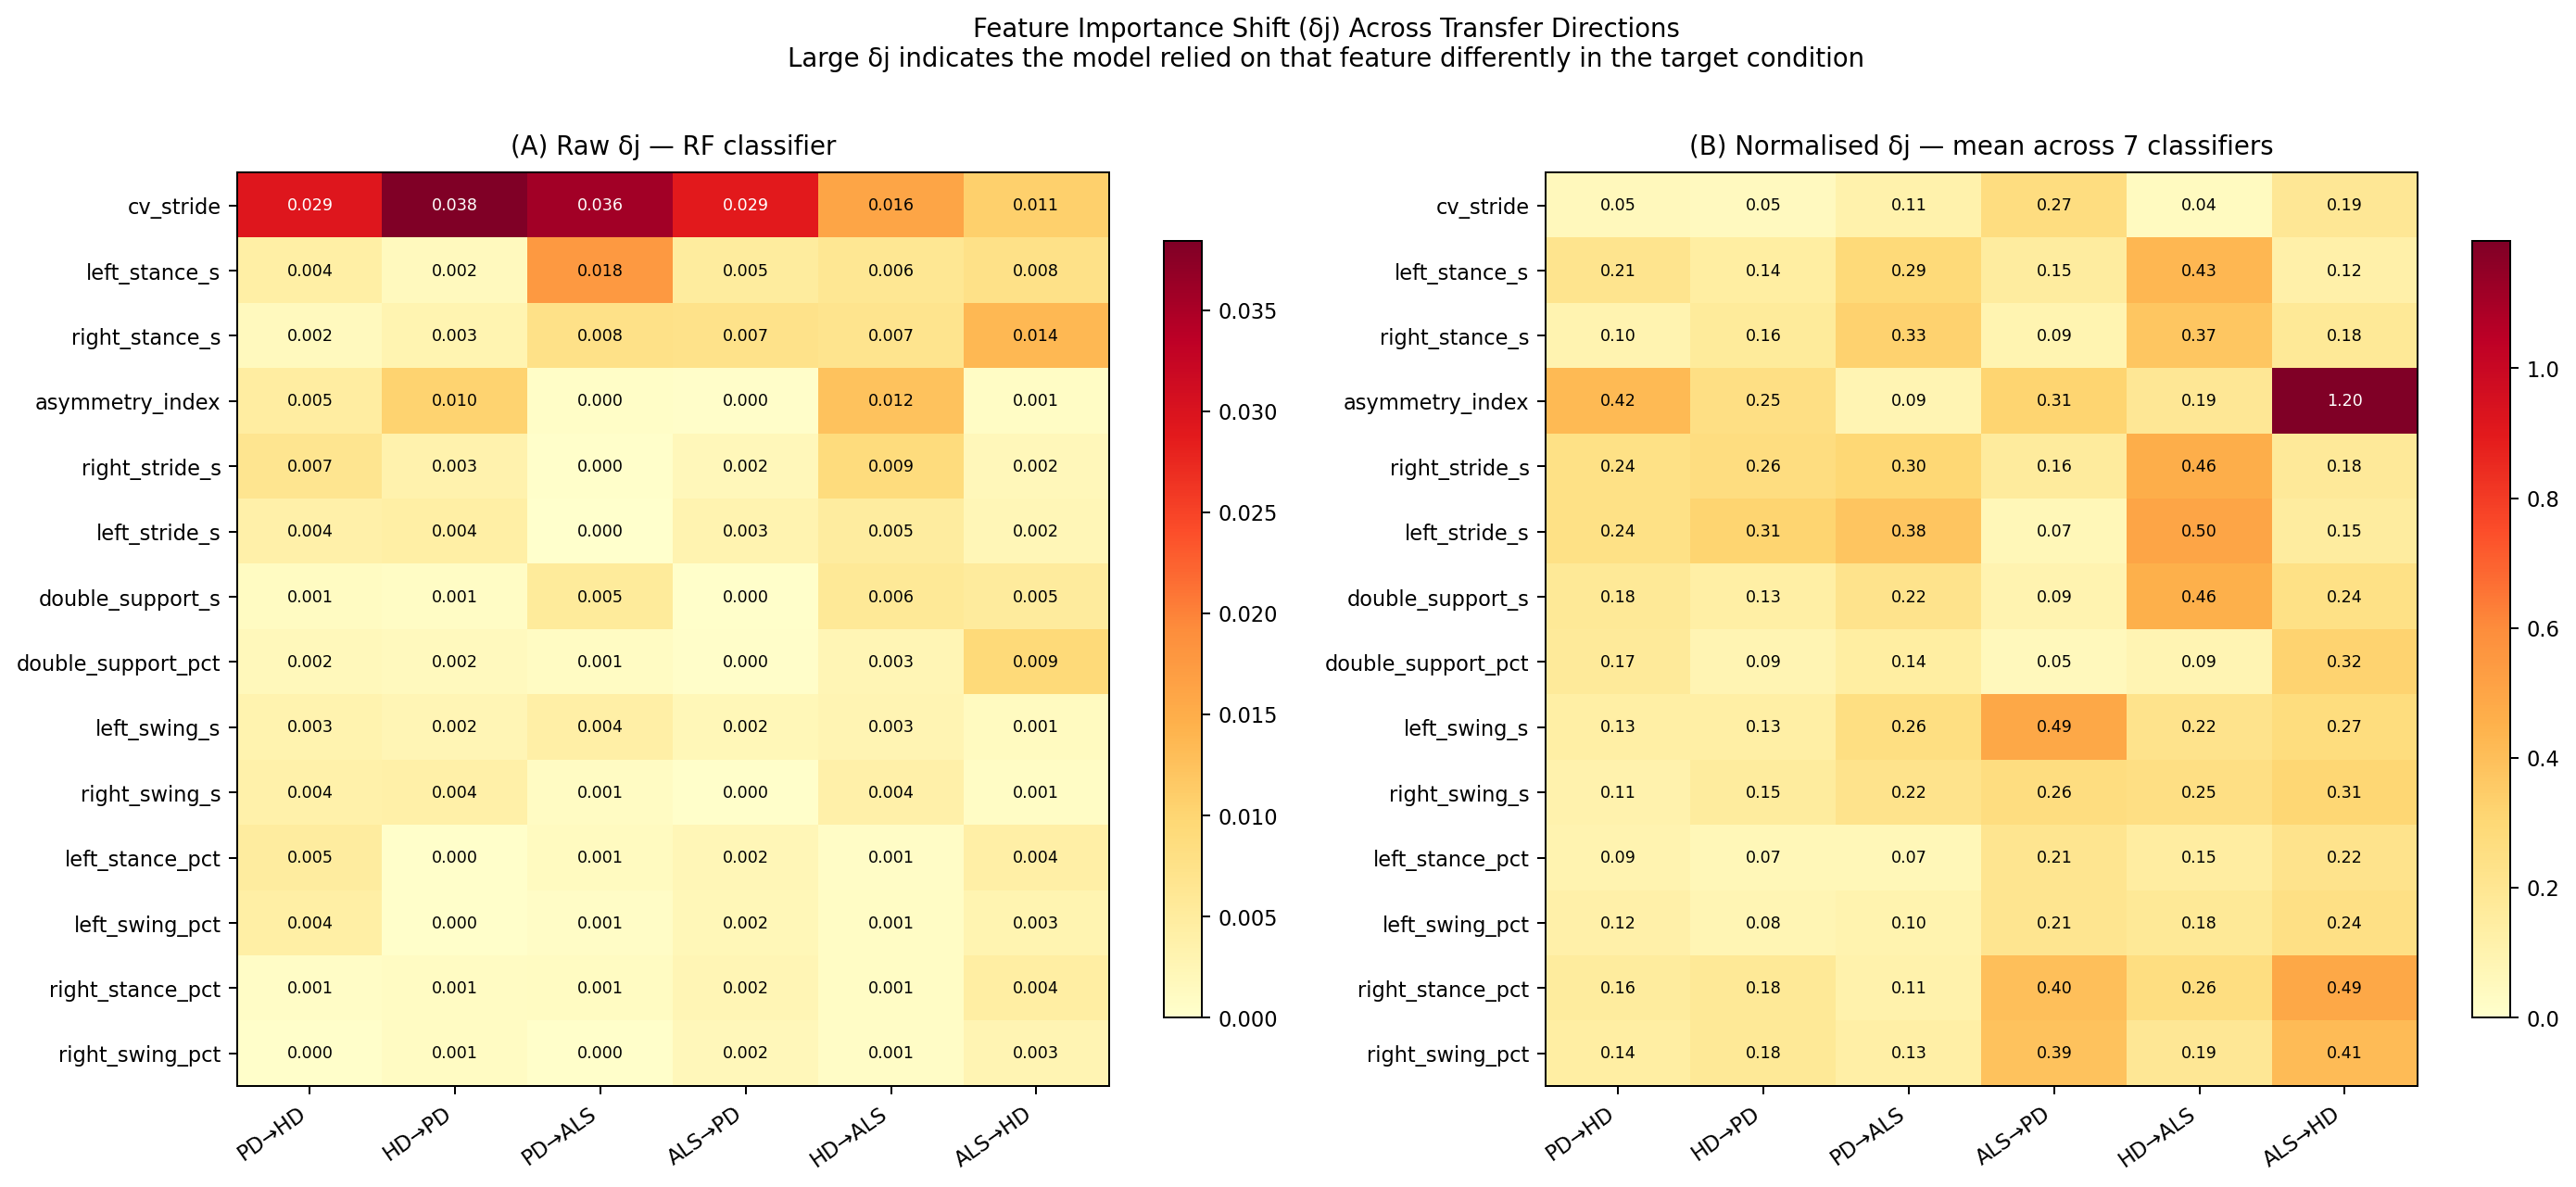

Saved delta_j_heatmap.pdf / .png


In [10]:
# RF raw δj: shape (14, 6)
dj_rf = delta_j_matrix[:, :, 0]          # classifier index 0 = rf
# Cross-classifier mean normalised δj: shape (14, 6)
dj_norm_mean = delta_j_norm_matrix.mean(axis=2)   # mean over classifiers

# Sort rows by mean δj (RF) across all 6 directions so the most shifting features appear at top
row_order = np.argsort(dj_rf.mean(axis=1))[::-1]
feat_labels_sorted = [ALL_FEATURE_COLS[i] for i in row_order]
dj_rf_sorted       = dj_rf[row_order, :]
dj_norm_sorted     = dj_norm_mean[row_order, :]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, title, fmt in zip(
    axes,
    [dj_rf_sorted, dj_norm_sorted],
    ['(A) Raw δj — RF classifier', '(B) Normalised δj — mean across 7 classifiers'],
    ['{:.3f}', '{:.2f}'],
):
    im = ax.imshow(data, cmap='YlOrRd', aspect='auto', vmin=0)
    ax.set_xticks(range(n_dirs))
    ax.set_xticklabels(DIR_LABELS, rotation=35, ha='right')
    ax.set_yticks(range(n_feats))
    ax.set_yticklabels(feat_labels_sorted)
    ax.set_title(title, pad=8)
    plt.colorbar(im, ax=ax, shrink=0.85)
    for i in range(n_feats):
        for j in range(n_dirs):
            val = data[i, j]
            txt_color = 'white' if val > 0.6 * data.max() else 'black'
            ax.text(j, i, fmt.format(val), ha='center', va='center',
                    fontsize=7, color=txt_color)

fig.suptitle(
    'Feature Importance Shift (δj) Across Transfer Directions\n'
    'Large δj indicates the model relied on that feature differently in the target condition',
    fontsize=11, y=1.01,
)
fig.tight_layout()

fig.savefig(FIGURES_PDF / 'delta_j_heatmap.pdf')
fig.savefig(FIGURES_PNG / 'delta_j_heatmap.png')
plt.show()
print('Saved delta_j_heatmap.pdf / .png')

### Cell 3 — Cross-Classifier δj Consistency (Spearman Correlation)

For each of the 6 transfer directions, computes a **7×7 Spearman rank correlation matrix** of the 14-dimensional δj vectors across classifiers. Entry (i, j) answers: “Do classifier i and classifier j agree on which features shift most for this direction?”

**Scientific significance:** If all classifiers show high mutual correlation (dark green cells), the δj pattern is a property of the **biomechanics** — a genuinely condition-specific feature that every algorithm family detects. If correlations are low, the failure mechanism is classifier-specific, which is itself an informative finding about how algorithmic families respond to distribution shift.

**What to look for:** Tree-based classifiers (RF, DT, XGBoost, LightGBM) are expected to correlate more strongly with each other than with SVM/KNN/QDA, since they operate on the same feature split logic. Very low correlations between kernel/distance methods and tree methods would indicate that the feature shift diagnosis depends on the algorithm family.

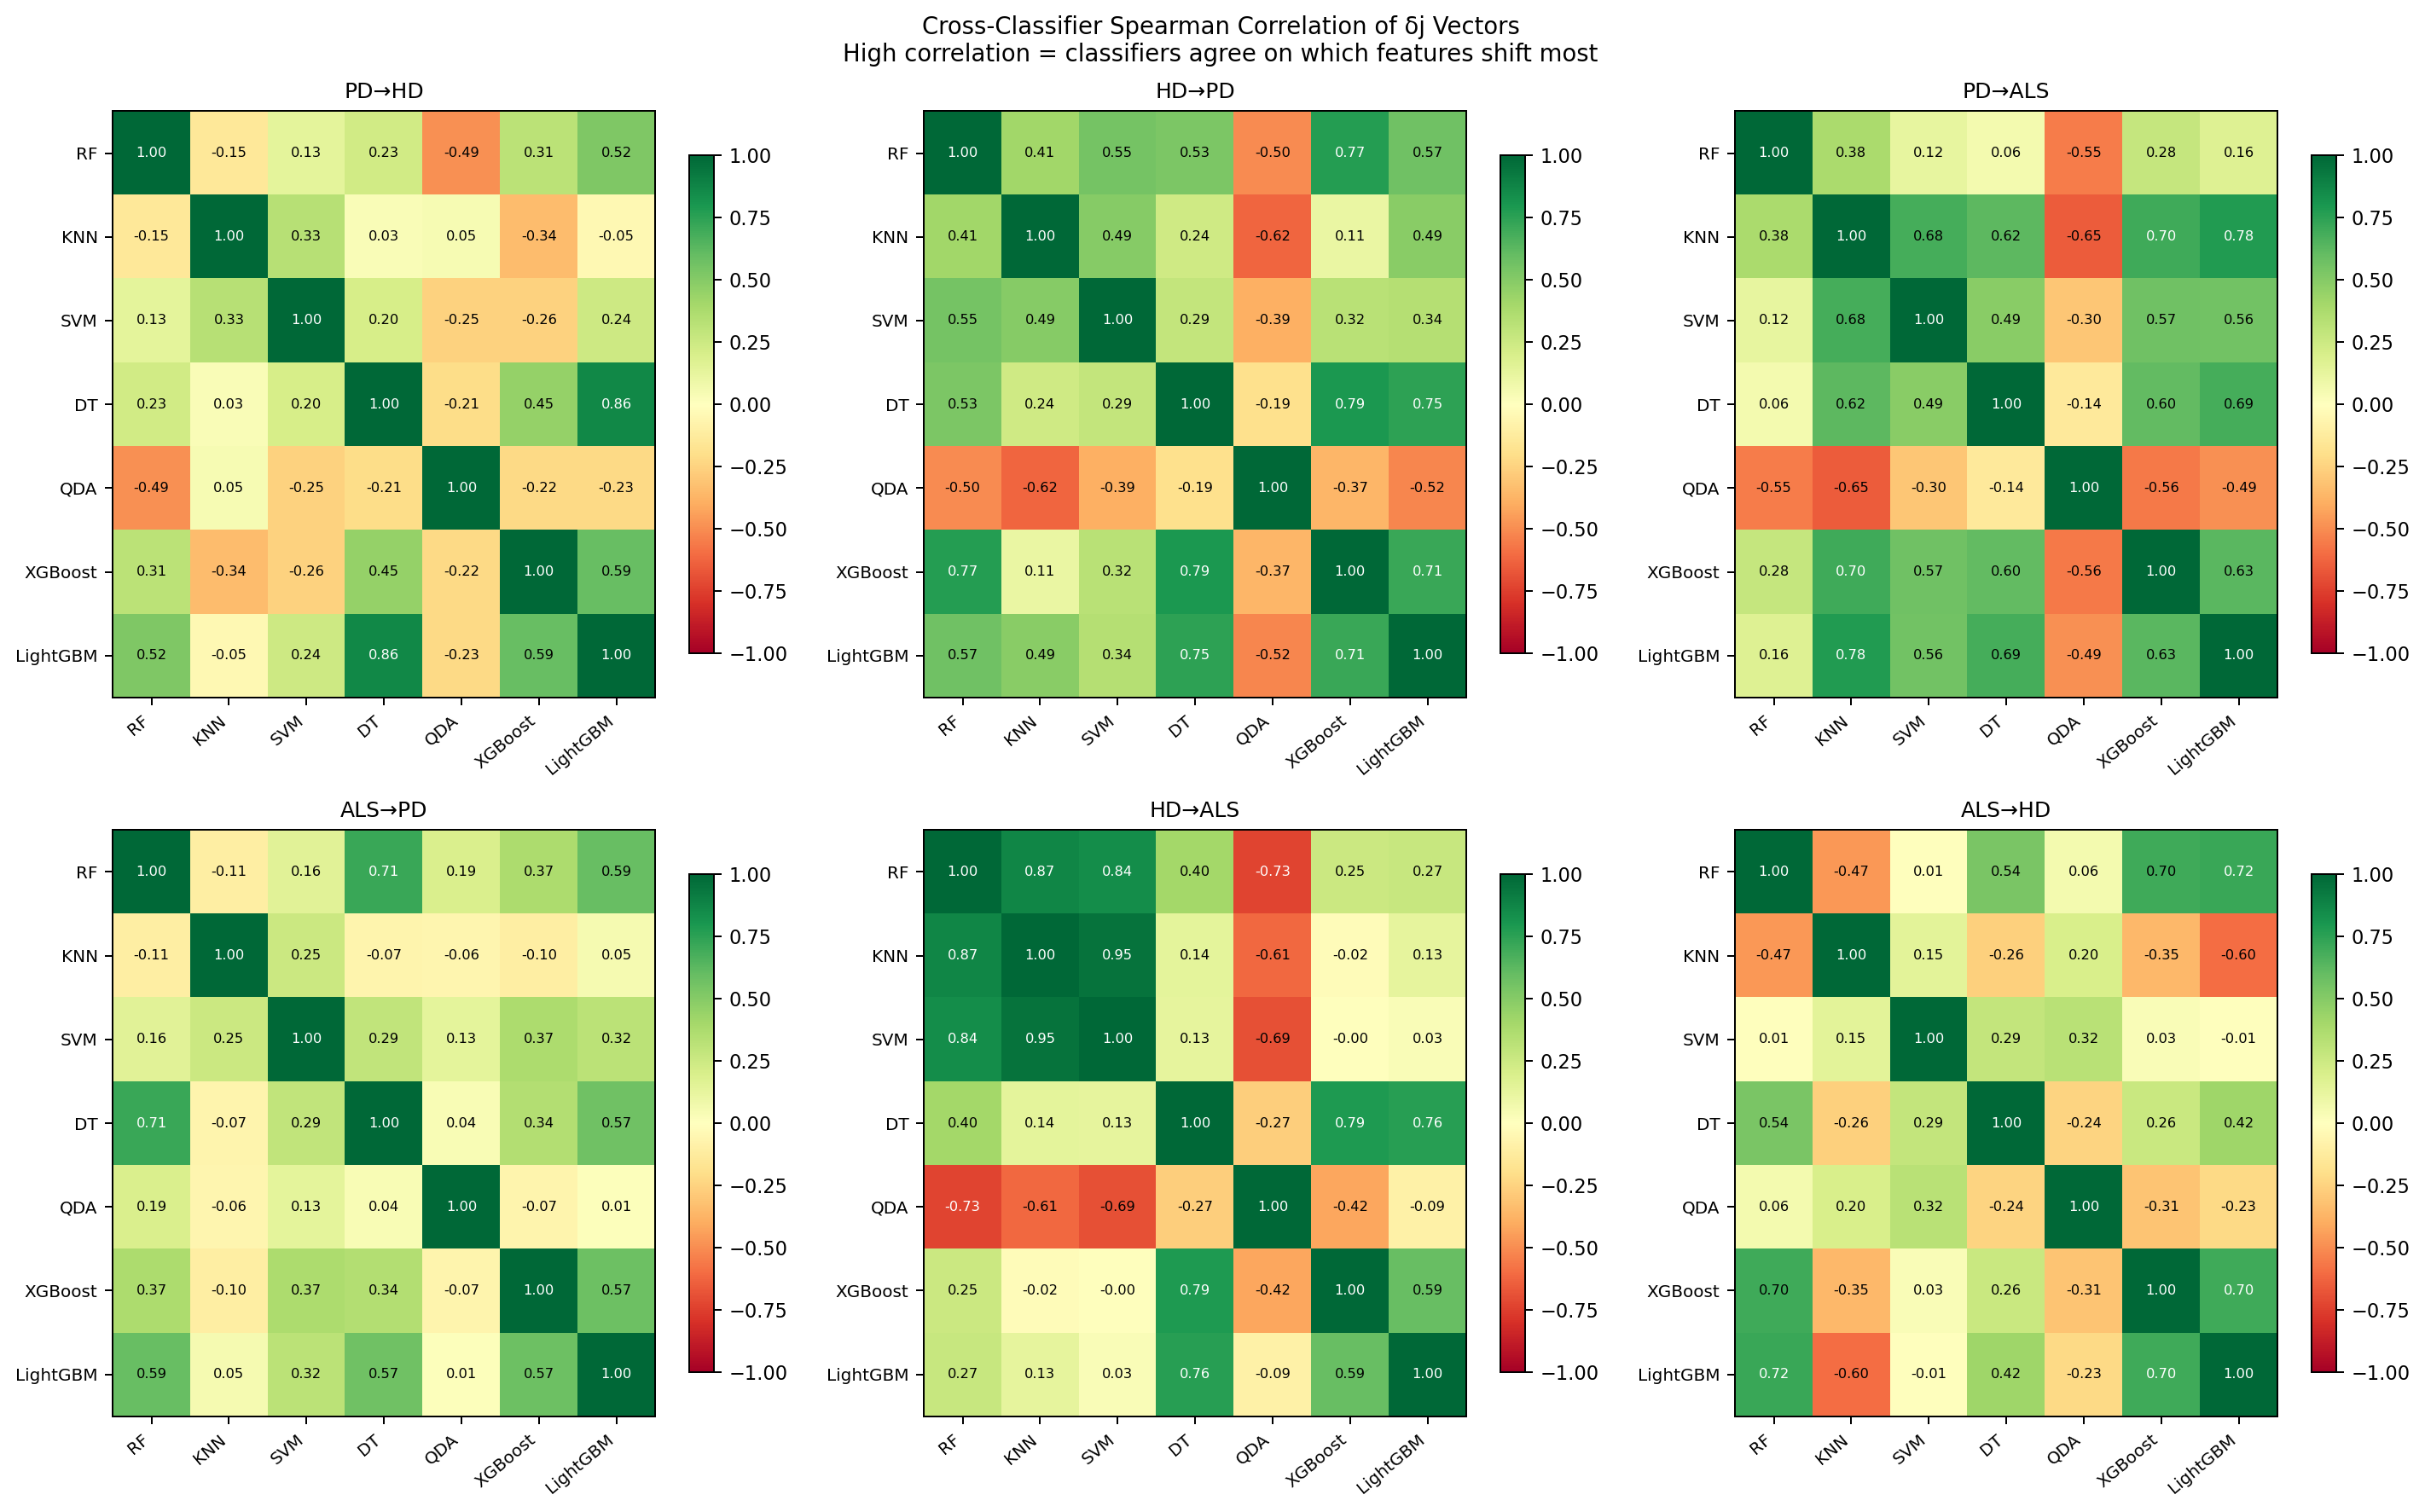

Saved delta_j_spearman.pdf / .png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.ravel()

for di, (d, dl) in enumerate(zip(DIRECTIONS, DIR_LABELS)):
    ax = axes_flat[di]
    dj_block = delta_j_matrix[:, di, :]   # (14, 7)
    corr_mat = np.zeros((n_clfs, n_clfs))
    for ci in range(n_clfs):
        for cj in range(n_clfs):
            rho, _ = stats.spearmanr(dj_block[:, ci], dj_block[:, cj])
            corr_mat[ci, cj] = rho

    im = ax.imshow(corr_mat, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(n_clfs))
    ax.set_xticklabels(CLF_LABELS, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(n_clfs))
    ax.set_yticklabels(CLF_LABELS, fontsize=8)
    ax.set_title(dl, fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.85)
    for ci in range(n_clfs):
        for cj in range(n_clfs):
            ax.text(cj, ci, f'{corr_mat[ci, cj]:.2f}', ha='center', va='center',
                    fontsize=6.5,
                    color='white' if abs(corr_mat[ci, cj]) > 0.7 else 'black')

fig.suptitle(
    'Cross-Classifier Spearman Correlation of δj Vectors\n'
    'High correlation = classifiers agree on which features shift most',
    fontsize=11,
)
fig.tight_layout()

fig.savefig(FIGURES_PDF / 'delta_j_spearman.pdf')
fig.savefig(FIGURES_PNG / 'delta_j_spearman.png')
plt.show()
print('Saved delta_j_spearman.pdf / .png')

### Cell 4 — SHAP Mean Absolute Importance: Within vs Cross (RF Only)

Six paired horizontal bar charts — one per transfer direction — showing RF’s **mean absolute SHAP value** for each feature in two settings:

- **Blue (within-condition):** How much the RF model relied on each feature when classifying strides from the source condition against Control Group A during LOSO-CV.
- **Red (cross-condition):** How much the same fitted model relied on each feature when applied zero-shot to the target condition.

Features are sorted by within-condition importance (ascending, so the most important feature is at the top of each chart). The **gap between blue and red** is the visual representation of δj.

**What to look for:** `cv_stride` showing the largest blue bar for HD-source directions and the largest gap between blue and red. For ALS-source directions, stance-time features (`left_stance_s`, `right_stance_s`) expected to dominate. Features where the red bar exceeds the blue bar represent *increased* reliance cross-condition.

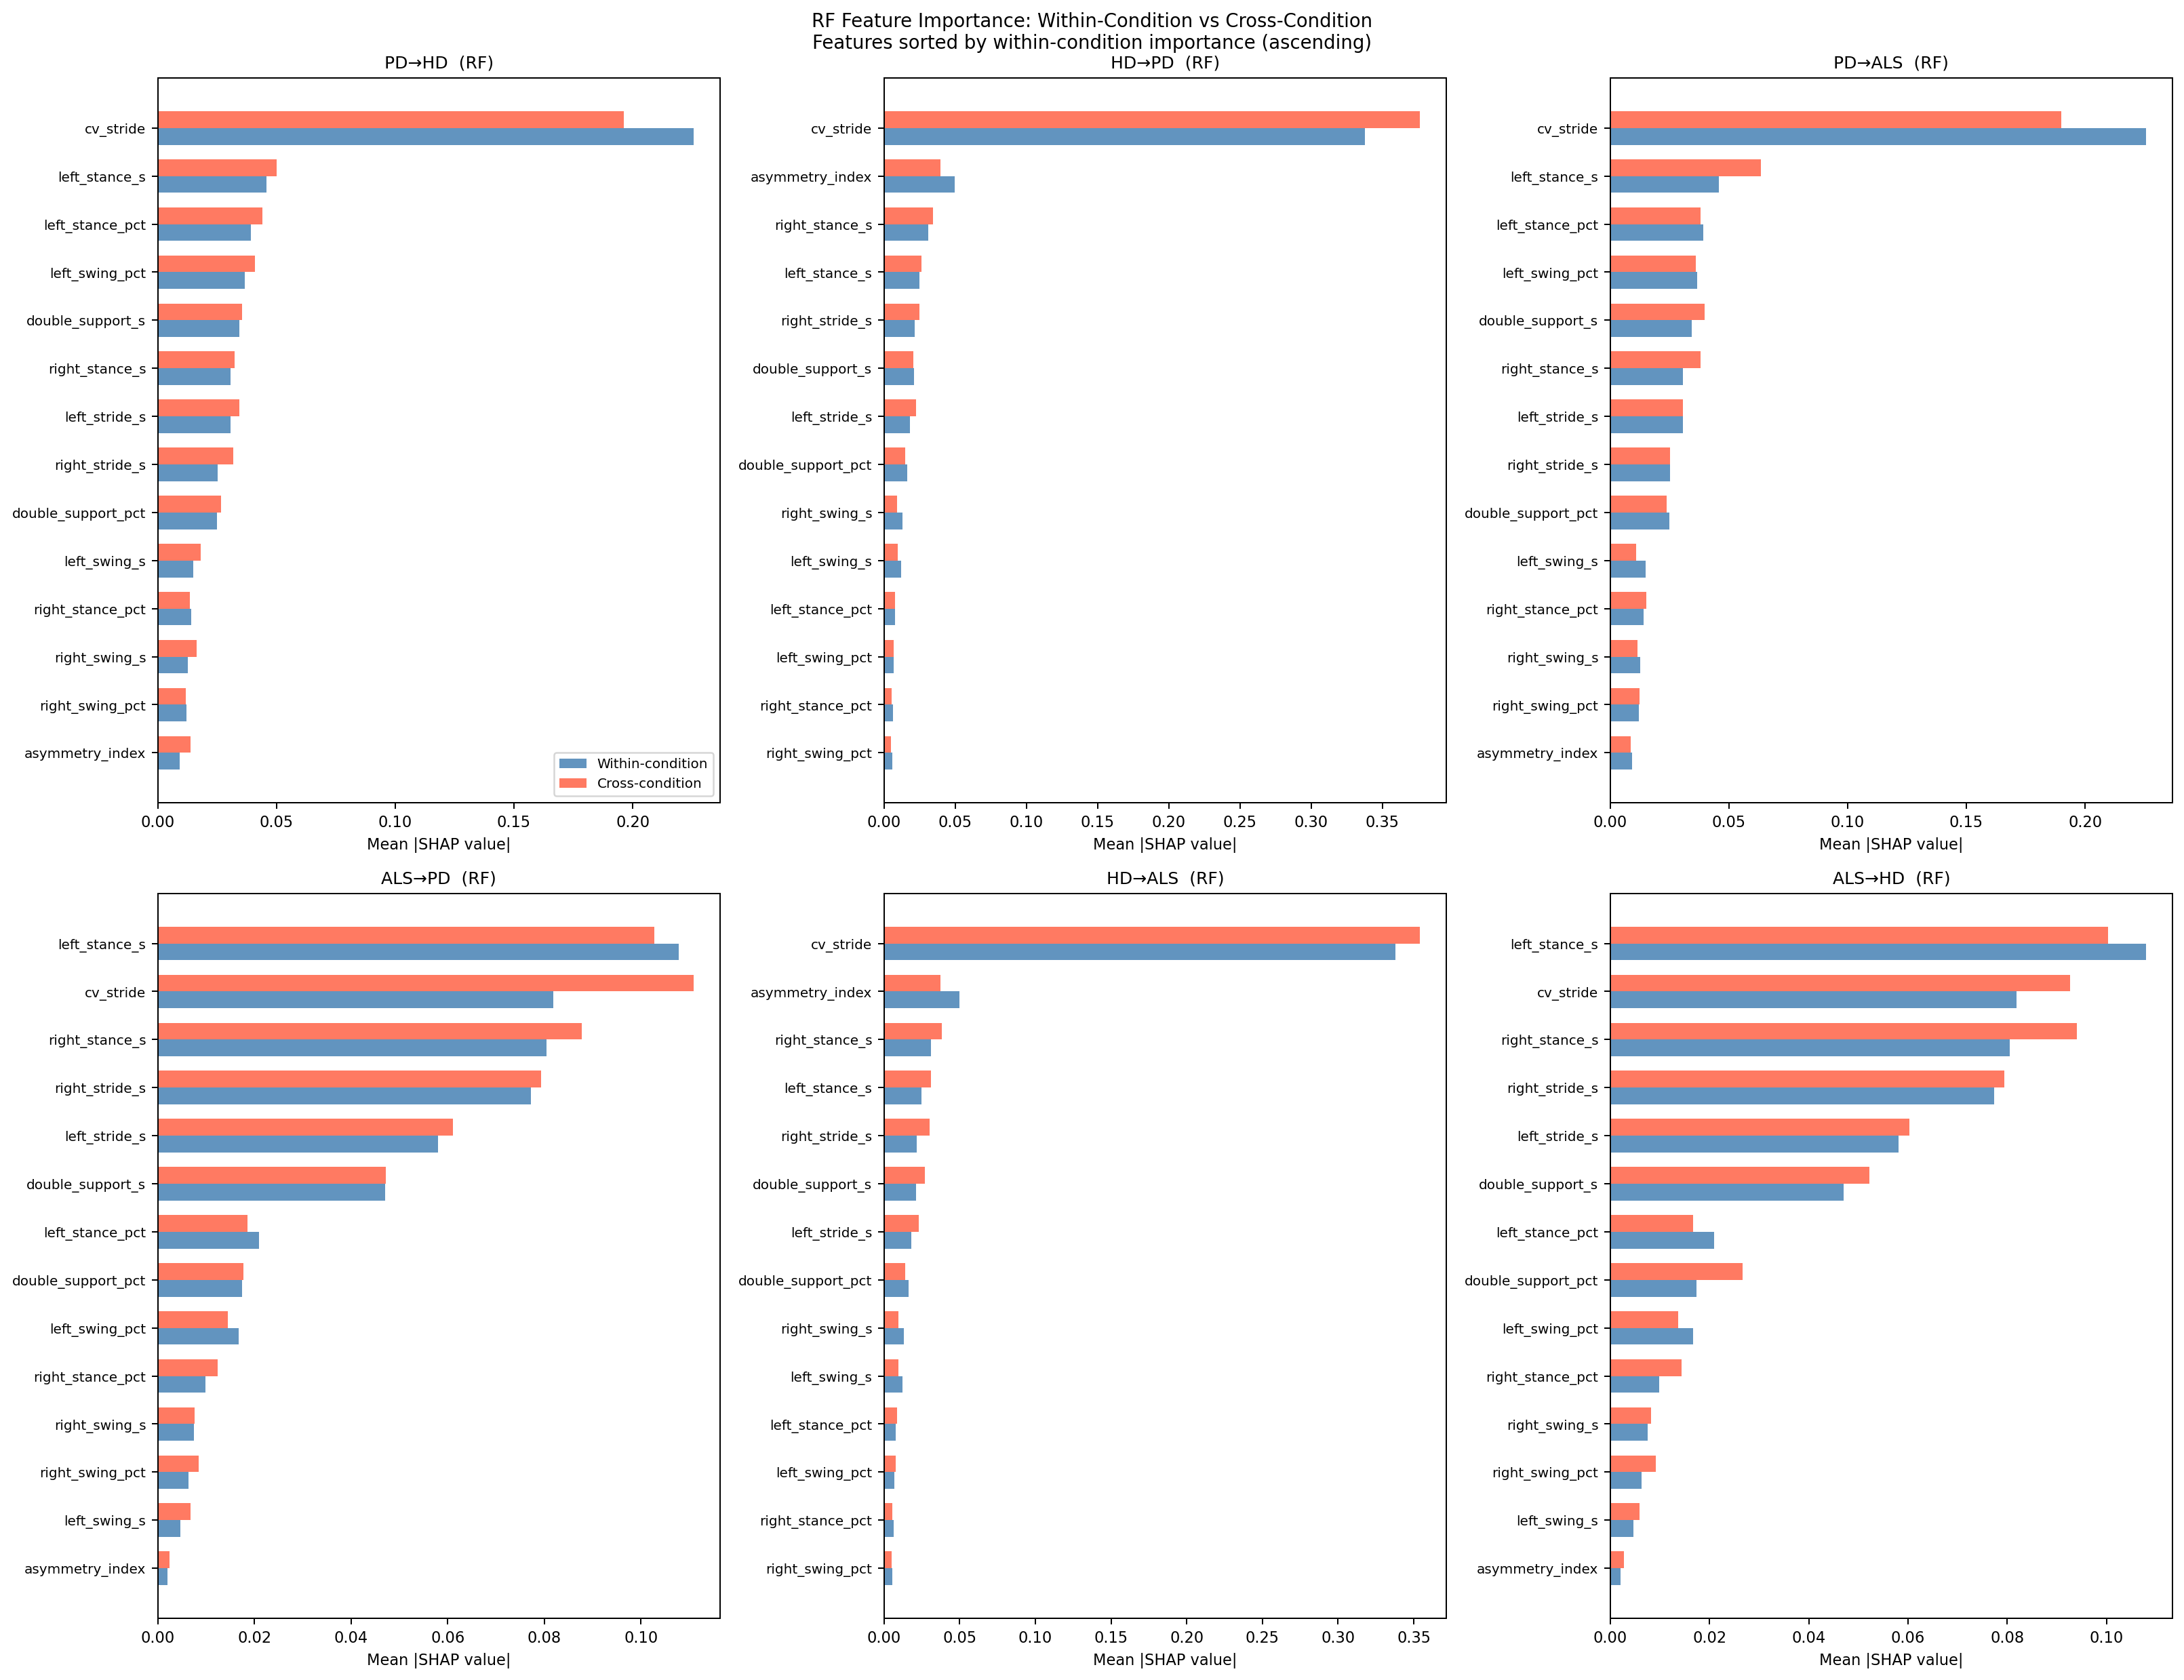

Saved shap_importance_within_vs_cross.pdf / .png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 14))
axes_flat = axes.ravel()

rf_ci = CLF_NAMES.index('rf')   # 0

for di, (d, dl) in enumerate(zip(DIRECTIONS, DIR_LABELS)):
    ax = axes_flat[di]
    within = mean_abs_within_mat[:, di, rf_ci]
    cross  = mean_abs_cross_mat[:, di, rf_ci]

    # Sort ascending so most important feature appears at the top in barh
    order = np.argsort(within)
    feat_names = [ALL_FEATURE_COLS[i] for i in order]
    w_sorted   = within[order]
    c_sorted   = cross[order]

    y = np.arange(n_feats)
    height = 0.35
    ax.barh(y - height/2, w_sorted, height, label='Within-condition', color='steelblue', alpha=0.85)
    ax.barh(y + height/2, c_sorted, height, label='Cross-condition',  color='tomato',    alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(feat_names, fontsize=8)
    ax.set_xlabel('Mean |SHAP value|', fontsize=9)
    ax.set_title(f'{dl}  (RF)', fontsize=10)
    if di == 0:
        ax.legend(fontsize=8)

fig.suptitle(
    'RF Feature Importance: Within-Condition vs Cross-Condition\n'
    'Features sorted by within-condition importance (ascending)',
    fontsize=11,
)
fig.tight_layout()

fig.savefig(FIGURES_PDF / 'shap_importance_within_vs_cross.pdf')
fig.savefig(FIGURES_PNG / 'shap_importance_within_vs_cross.png')
plt.show()
print('Saved shap_importance_within_vs_cross.pdf / .png')

### Cell 5 — Top δj Features Summary Table

A ranked table of the **top-3 transfer-failure features per direction** for the RF classifier, showing both raw δj (absolute shift) and normalised δj (fractional shift relative to within-condition importance).

The table confirms: `cv_stride` appears as rank-1 for 5 of 6 directions; stance features (`left_stance_s`, `right_stance_s`) dominate in ALS-source and ALS-target directions; `asymmetry_index` appears in HD-source directions.

The matplotlib version uses per-cell background colors computed by mapping each cell’s value through the `YlOrRd` colormap with luminance-based text color selection, matching the pandas `background_gradient` display.

,Direction,Rank,Feature,δj (raw),δj (norm)
0,PD→HD,1,cv_stride,0.0293,0.1300
1,PD→HD,2,right_stride_s,0.0067,0.2666
2,PD→HD,3,left_stance_pct,0.0048,0.1226
3,HD→PD,1,cv_stride,0.0384,0.1137
4,HD→PD,2,asymmetry_index,0.0103,0.2078
5,HD→PD,3,left_stride_s,0.0043,0.2360
6,PD→ALS,1,cv_stride,0.0357,0.1581
7,PD→ALS,2,left_stance_s,0.0176,0.3850
8,PD→ALS,3,right_stance_s,0.0075,0.2465
9,ALS→PD,1,cv_stride,0.0289,0.3532


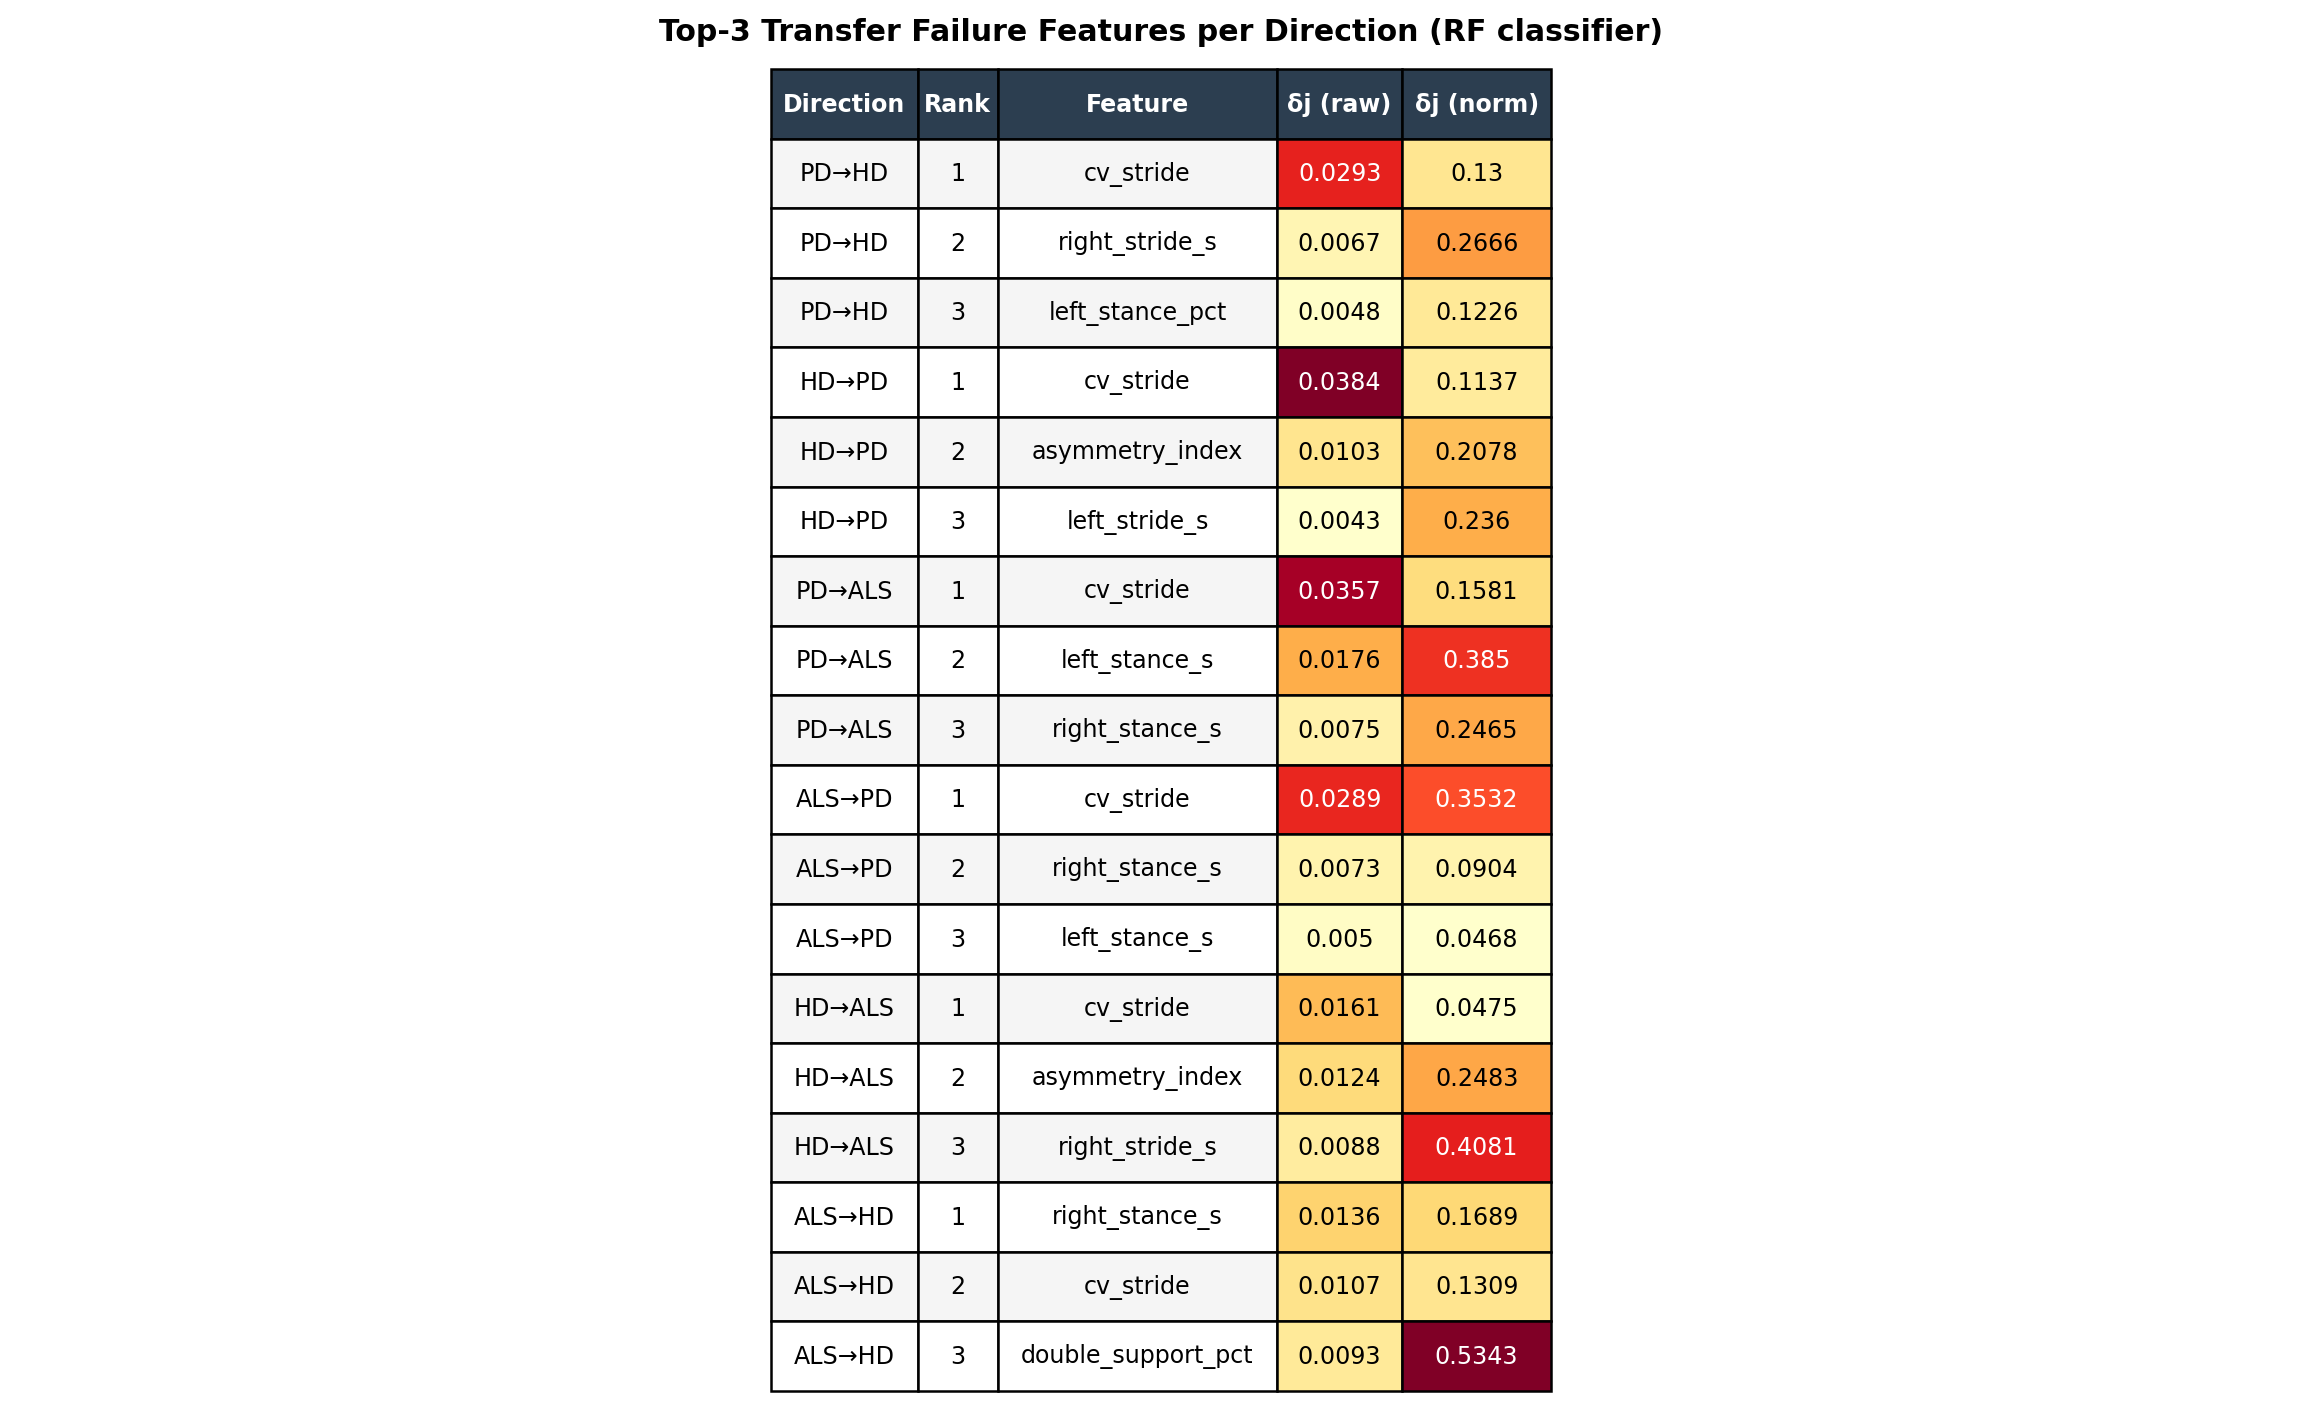

Saved top_delta_j_table.pdf / .png


In [13]:
rf_ci = CLF_NAMES.index('rf')

rows = []
for di, (d, dl) in enumerate(zip(DIRECTIONS, DIR_LABELS)):
    dj_raw  = delta_j_matrix[:, di, rf_ci]
    dj_norm = delta_j_norm_matrix[:, di, rf_ci]
    top3 = np.argsort(dj_raw)[::-1][:3]
    for rank, idx in enumerate(top3, 1):
        rows.append({
            'Direction': dl,
            'Rank':      rank,
            'Feature':   ALL_FEATURE_COLS[idx],
            'δj (raw)':  round(float(dj_raw[idx]), 4),
            'δj (norm)': round(float(dj_norm[idx]), 4),
        })

df_top3 = pd.DataFrame(rows)

# HTML display with pandas gradient
display(
    df_top3.style
    .set_caption('Top-3 Transfer Failure Features per Direction (RF classifier)')
    .background_gradient(subset=['δj (raw)', 'δj (norm)'], cmap='YlOrRd')
    .format({'δj (raw)': '{:.4f}', 'δj (norm)': '{:.4f}'})
)

# Matplotlib version — per-cell color intensity on the two δj columns
col_labels = list(df_top3.columns)
cell_text  = df_top3.astype(str).values.tolist()

dj_raw_vals  = df_top3['δj (raw)'].values.astype(float)
dj_norm_vals = df_top3['δj (norm)'].values.astype(float)
norm_raw  = Normalize(vmin=dj_raw_vals.min(),  vmax=dj_raw_vals.max())
norm_norm = Normalize(vmin=dj_norm_vals.min(), vmax=dj_norm_vals.max())
cmap_tbl  = cm.get_cmap('YlOrRd')

# Pre-compute per-cell colour lists so we can pass cellColours to table()
n_rows = len(cell_text)
n_cols = len(col_labels)
cell_colors = []
for data_row in range(n_rows):
    row_colors = []
    for col in range(n_cols):
        if col == 3:   # δj (raw)
            rgba = cmap_tbl(norm_raw(dj_raw_vals[data_row]))
            row_colors.append(rgba)
        elif col == 4:   # δj (norm)
            rgba = cmap_tbl(norm_norm(dj_norm_vals[data_row]))
            row_colors.append(rgba)
        elif data_row % 2 == 0:
            row_colors.append('#f5f5f5')
        else:
            row_colors.append('#ffffff')
    cell_colors.append(row_colors)

fig_t, ax_t = plt.subplots(figsize=(13, 8))
ax_t.axis('off')

tbl = ax_t.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellColours=cell_colors,
    cellLoc='center',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.auto_set_column_width(col=list(range(n_cols)))
tbl.scale(1, 2.2)

# Header row: dark background, white bold text
for j in range(n_cols):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].get_text().set_color('white')
    tbl[0, j].get_text().set_fontweight('bold')

# Set text colour for δj cells based on luminance of their background
for data_row in range(n_rows):
    for col in [3, 4]:
        rgba = cell_colors[data_row][col]
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        tbl[data_row + 1, col].get_text().set_color(
            'white' if luminance < 0.5 else 'black'
        )

fig_t.text(0.5, 0.97,
           'Top-3 Transfer Failure Features per Direction (RF classifier)',
           ha='center', va='top', fontsize=12, fontweight='bold')
fig_t.tight_layout(rect=[0, 0, 1, 0.95])

fig_t.savefig(FIGURES_PDF / 'top_delta_j_table.pdf')
fig_t.savefig(FIGURES_PNG / 'top_delta_j_table.png')
plt.show()
plt.close(fig_t)
print('Saved top_delta_j_table.pdf / .png')


### Cell 6 — Emerged Features Analysis

**Emerged features** are features where `mean(|φj_within|) < 1e-3` — the model assigned near-zero importance to that feature in the source condition — but `δj > 0`, meaning its importance shifted when applied cross-condition. The model began relying on a feature it previously ignored.

From the data inspection, emerged features are concentrated in XGBoost and LightGBM, primarily `right_swing_pct`, `right_swing_s`, and stance-related percentage features. This is consistent with gradient-boosting dynamics: XGB/LGB may down-weight swing percentage features within-condition (collinear with stride time features) but those features become active when the cross-condition distribution shifts the collinearity structure.

**What to look for:** `right_swing_pct` expected in the most pairs (~8), primarily for XGB and LightGBM. RF, SVM, KNN, and QDA expected to show no emerged features.

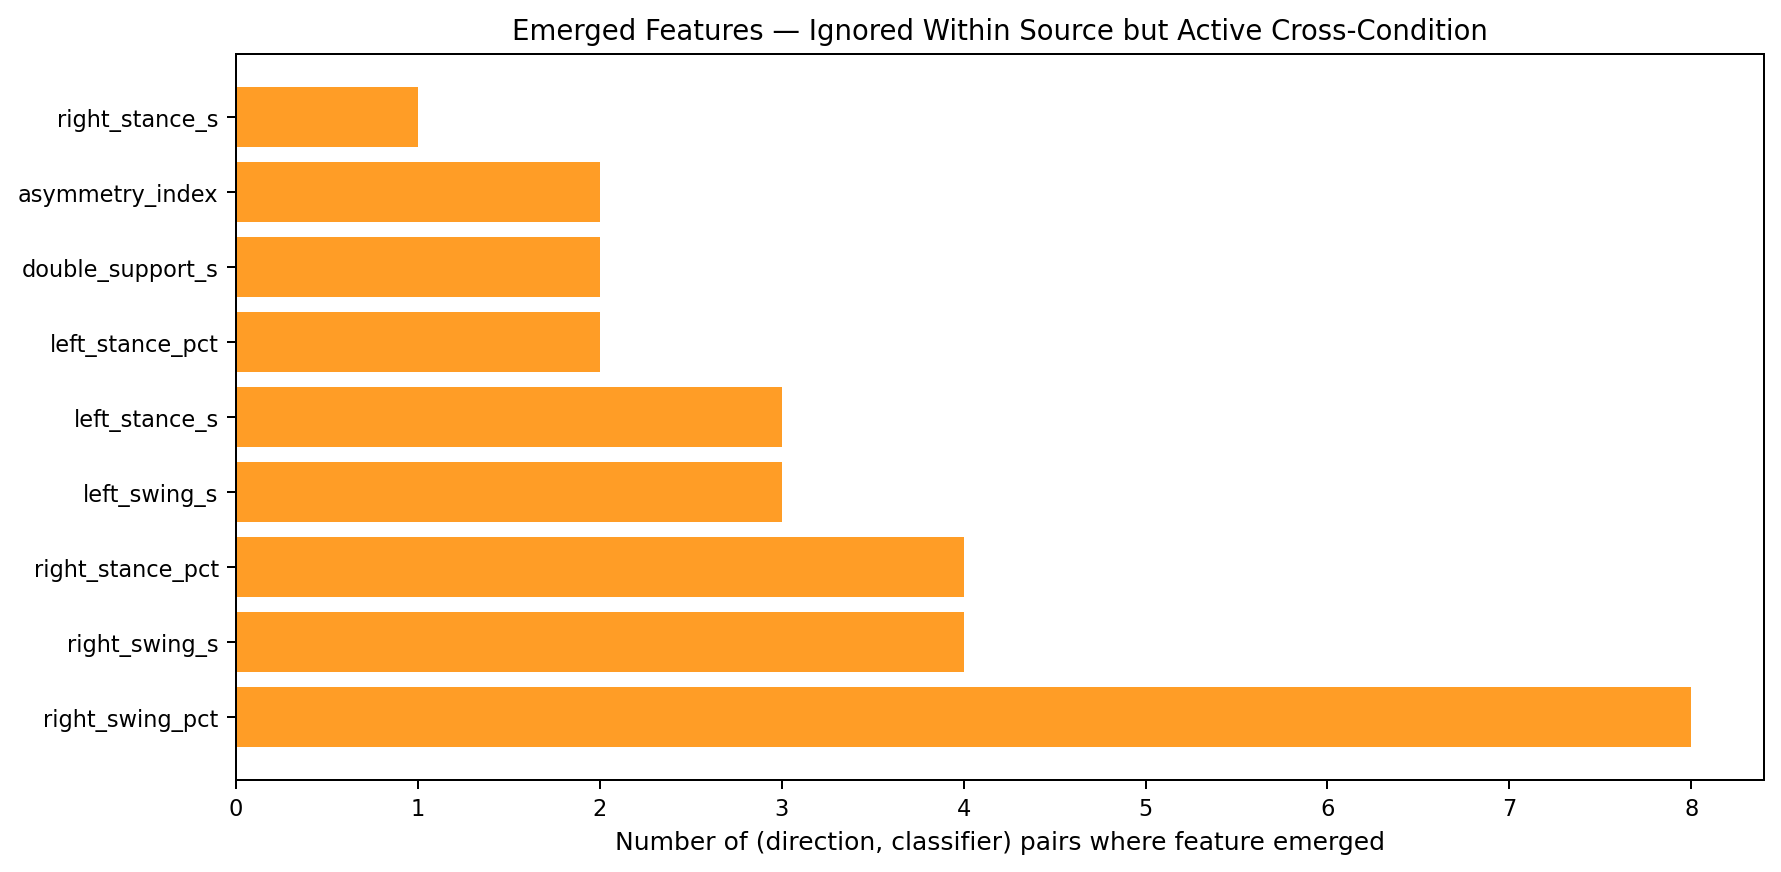

Saved emerged_features.pdf / .png

Emergence detail (feature: [direction/classifier pairs]):
  right_swing_pct: ['PD→HD/XGBoost', 'PD→HD/LightGBM', 'HD→PD/XGBoost', 'HD→PD/LightGBM', 'PD→ALS/XGBoost', 'PD→ALS/LightGBM', 'HD→ALS/XGBoost', 'HD→ALS/LightGBM']
  right_swing_s: ['PD→HD/LightGBM', 'HD→PD/LightGBM', 'PD→ALS/LightGBM', 'HD→ALS/LightGBM']
  right_stance_pct: ['HD→PD/XGBoost', 'HD→PD/LightGBM', 'HD→ALS/XGBoost', 'HD→ALS/LightGBM']
  left_swing_s: ['HD→PD/XGBoost', 'HD→PD/LightGBM', 'HD→ALS/XGBoost']
  left_stance_s: ['HD→PD/XGBoost', 'HD→PD/LightGBM', 'HD→ALS/XGBoost']
  left_stance_pct: ['HD→PD/LightGBM', 'HD→ALS/LightGBM']
  double_support_s: ['HD→PD/XGBoost', 'HD→ALS/XGBoost']
  asymmetry_index: ['PD→HD/XGBoost', 'PD→ALS/XGBoost']
  right_stance_s: ['HD→PD/XGBoost']


In [14]:
emerge_count = np.zeros(n_feats, dtype=int)
emerge_details = {feat: [] for feat in ALL_FEATURE_COLS}

for di, (d, dl) in enumerate(zip(DIRECTIONS, DIR_LABELS)):
    for ci, (clf, cl) in enumerate(zip(CLF_NAMES, CLF_LABELS)):
        for fidx in shap_res[d][clf]['emerged_features']:
            emerge_count[fidx] += 1
            emerge_details[ALL_FEATURE_COLS[fidx]].append(f'{dl}/{cl}')

if emerge_count.sum() == 0:
    print('No emerged features across all 42 (direction, classifier) pairs.')
    print('All features had mean(|φj_within|) ≥ 1e-3 in every source condition.')
else:
    active_feats = [(ALL_FEATURE_COLS[i], emerge_count[i])
                    for i in range(n_feats) if emerge_count[i] > 0]
    active_feats.sort(key=lambda x: x[1], reverse=True)

    feat_names_plot = [x[0] for x in active_feats]
    counts_plot     = [x[1] for x in active_feats]

    fig, ax = plt.subplots(figsize=(10, max(3, len(feat_names_plot) * 0.55)))
    y = np.arange(len(feat_names_plot))
    ax.barh(y, counts_plot, color='darkorange', alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(feat_names_plot)
    ax.set_xlabel('Number of (direction, classifier) pairs where feature emerged')
    ax.set_title('Emerged Features — Ignored Within Source but Active Cross-Condition')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    fig.tight_layout()

    fig.savefig(FIGURES_PDF / 'emerged_features.pdf')
    fig.savefig(FIGURES_PNG / 'emerged_features.png')
    plt.show()
    print('Saved emerged_features.pdf / .png')
    print()

    print('Emergence detail (feature: [direction/classifier pairs]):')
    for feat, _ in active_feats:
        print(f'  {feat}: {emerge_details[feat]}')

### Cell 7 — δj vs ΔF1 Correlation Scatter

Tests the central hypothesis: **does a larger feature importance shift predict larger performance degradation?** For each of the 42 (direction × classifier) pairs, plots `max normalised δj` (x-axis) against `ΔF1 = within F1 − cross F1` (y-axis).

**Statistical approach:** Spearman rank correlation is used (rather than Pearson) because both δj and ΔF1 are bounded, non-normally distributed quantities. Pearson is also reported for completeness.

**Two levels of analysis:**
1. **Per-condition regression lines (solid):** Tests whether the δj→ΔF1 relationship holds *within* each source condition across its 14 classifier points. This is the causally meaningful test — it separates the within-condition hypothesis from the between-condition cluster effect.
2. **Overall dashed line (secondary):** The aggregate relationship across all 42 points, which partly reflects that HD-source directions have both higher δj and higher ΔF1 simultaneously (a between-group effect).

**What to look for:** Overall Spearman ρ expected positive and significant (ρ≈0.37, p≈0.016). Per-condition Spearman values printed below the figure tell a richer story about whether the relationship holds within each source condition independently.

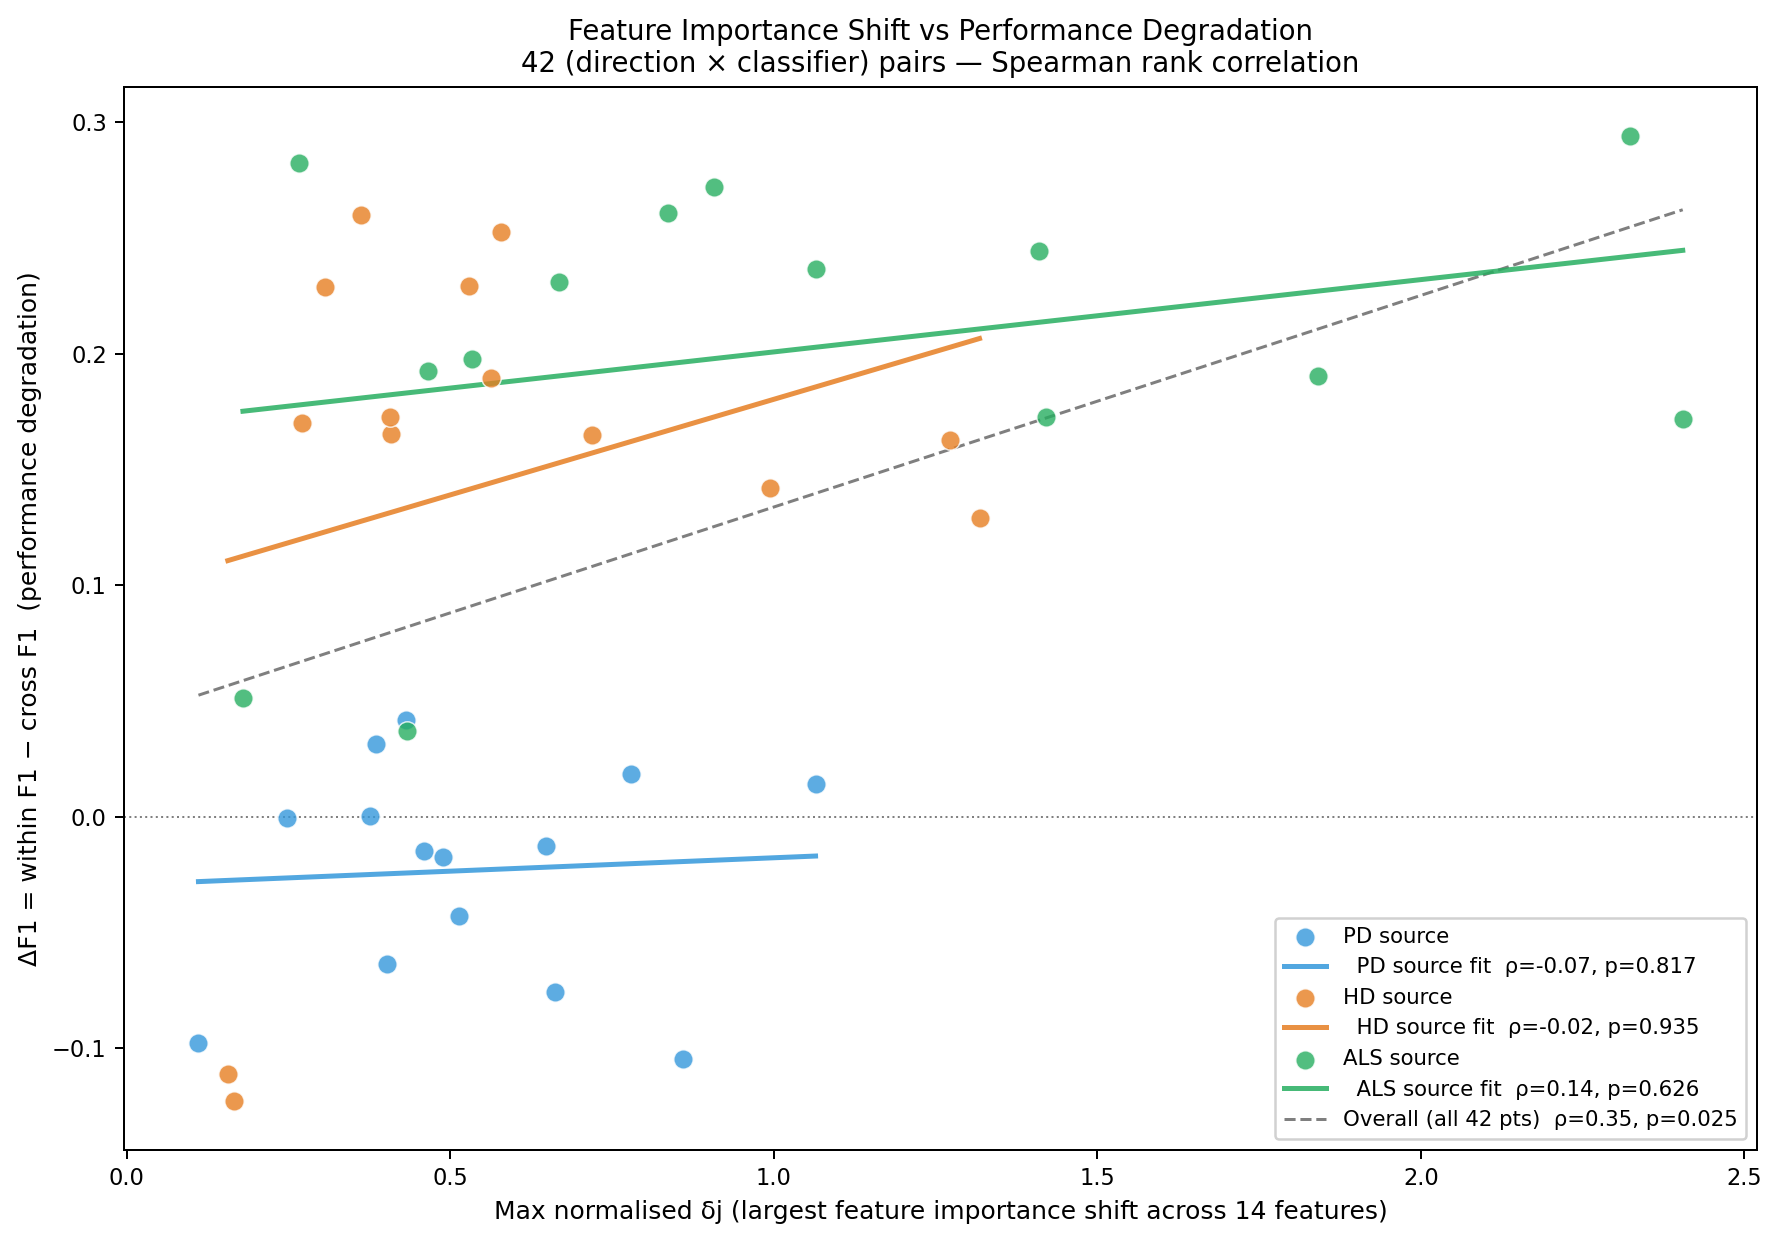

Overall Spearman ρ = 0.345,  p = 0.0251
Overall Pearson  r = 0.385,  p = 0.0118

PD source: Spearman ρ=-0.068 p=0.817  |  Pearson r=0.062 p=0.833  (n=14)
HD source: Spearman ρ=-0.024 p=0.935  |  Pearson r=0.264 p=0.362  (n=14)
ALS source: Spearman ρ=0.143 p=0.626  |  Pearson r=0.292 p=0.311  (n=14)


In [15]:
COND_COLORS = {'pd': '#3498db', 'hd': '#e67e22', 'als': '#27ae60'}
COND_LABELS_SC = {'pd': 'PD source', 'hd': 'HD source', 'als': 'ALS source'}

records = []
for di, (d, dl) in enumerate(zip(DIRECTIONS, DIR_LABELS)):
    src = SOURCE_FROM_DIR[d]
    for ci, (clf, cl) in enumerate(zip(CLF_NAMES, CLF_LABELS)):
        top_dj_norm = float(delta_j_norm_matrix[:, di, ci].max())
        within_f1   = WITHIN_F1_PER_CLF[src][clf]
        cross_f1    = cc[d]['classifiers'][clf]['f1_macro']
        delta_f1    = within_f1 - cross_f1
        records.append({
            'direction': dl, 'classifier': cl, 'source': src,
            'top_dj_norm': top_dj_norm, 'delta_f1': delta_f1,
        })

df_scatter = pd.DataFrame(records)

scatter_x_all = df_scatter['top_dj_norm'].values
scatter_y_all = df_scatter['delta_f1'].values

rho_overall, p_overall = stats.spearmanr(scatter_x_all, scatter_y_all)
r_pearson, p_pearson   = stats.pearsonr(scatter_x_all, scatter_y_all)

fig, ax = plt.subplots(figsize=(10, 7))

for src_cond in ['pd', 'hd', 'als']:
    mask = df_scatter['source'] == src_cond
    sx = df_scatter.loc[mask, 'top_dj_norm'].values
    sy = df_scatter.loc[mask, 'delta_f1'].values

    ax.scatter(sx, sy, c=COND_COLORS[src_cond], label=COND_LABELS_SC[src_cond],
               s=60, alpha=0.80, edgecolors='white', linewidths=0.6, zorder=3)

    if len(sx) > 2:
        slope, intercept = np.polyfit(sx, sy, 1)
        rho_cond, p_cond = stats.spearmanr(sx, sy)
        x_line = np.linspace(sx.min(), sx.max(), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, color=COND_COLORS[src_cond], linewidth=2.0,
                linestyle='-', alpha=0.85, zorder=2,
                label=f'  {COND_LABELS_SC[src_cond]} fit  ρ={rho_cond:.2f}, p={p_cond:.3f}')

# Overall reference line (secondary, dashed)
x_line_all = np.linspace(scatter_x_all.min(), scatter_x_all.max(), 100)
slope_all, intercept_all = np.polyfit(scatter_x_all, scatter_y_all, 1)
ax.plot(x_line_all, slope_all * x_line_all + intercept_all,
        color='black', linewidth=1.2, linestyle='--', alpha=0.5, zorder=1,
        label=f'Overall (all 42 pts)  ρ={rho_overall:.2f}, p={p_overall:.3f}')

ax.axhline(0, color='grey', linewidth=0.8, linestyle=':', zorder=0)
ax.set_xlabel('Max normalised δj (largest feature importance shift across 14 features)', fontsize=10)
ax.set_ylabel('ΔF1 = within F1 − cross F1  (performance degradation)', fontsize=10)
ax.set_title(
    'Feature Importance Shift vs Performance Degradation\n'
    '42 (direction × classifier) pairs — Spearman rank correlation',
    fontsize=11,
)
ax.legend(fontsize=8.5, framealpha=0.9)
fig.tight_layout()

fig.savefig(FIGURES_PDF / 'delta_j_vs_degradation.pdf')
fig.savefig(FIGURES_PNG / 'delta_j_vs_degradation.png')
plt.show()

print(f'Overall Spearman ρ = {rho_overall:.3f},  p = {p_overall:.4f}')
print(f'Overall Pearson  r = {r_pearson:.3f},  p = {p_pearson:.4f}')
print()
for src_cond in ['pd', 'hd', 'als']:
    mask = df_scatter['source'] == src_cond
    sx = df_scatter.loc[mask, 'top_dj_norm'].values
    sy = df_scatter.loc[mask, 'delta_f1'].values
    rho_c, p_c   = stats.spearmanr(sx, sy)
    r_c,   p_c2  = stats.pearsonr(sx, sy)
    print(f'{COND_LABELS_SC[src_cond]}: Spearman ρ={rho_c:.3f} p={p_c:.3f}  |  '
          f'Pearson r={r_c:.3f} p={p_c2:.3f}  (n={len(sx)})')

### Cell 7b — Alternative δj Summary Statistics: Sensitivity Analysis

The primary scatter (Cell 7) used `max(normalised δj)` as the summary of the 14-dimensional feature shift vector. This is a conservative summary that captures only the single largest shift. Three alternatives are tested here to assess sensitivity:

1. **Sum of raw δj:** Total disruption across all 14 features — captures breadth of shift as well as magnitude.
2. **Weighted δj:** Each feature's shift weighted by its within-condition importance — a shift on a heavily-used feature counts more than a shift on a near-zero-importance feature. Defined as Σⱼ mean_abs_within[j] × δj[j].
3. **L2 norm of δj:** Euclidean magnitude of the 14-dimensional shift vector — the most standard multivariate summary.

The theoretically most principled is **weighted δj**, since it accounts for whether the shifted features were actually consequential to the classifier's decision. A high shift on `right_swing_pct` (near-zero within-importance) is less disruptive than a high shift on `cv_stride` (high within-importance).

If any alternative shows substantially higher Spearman ρ with per-condition correlations also improving, that summary statistic is a better descriptor of transfer failure magnitude.

Summary statistic                    Overall ρ        p     PD ρ    HD ρ   ALS ρ
Max normalised δj (original)            +0.345   0.0251   -0.068  -0.024  +0.143 ◄
Sum of raw δj                           +0.225   0.1513   +0.367  -0.156  +0.112
Weighted δj (within-imp × δj)           +0.276   0.0771   +0.420  +0.253  +0.121
L2 norm of δj                           +0.261   0.0950   +0.521  -0.051  +0.015

Best overall Spearman ρ: 'Max normalised δj (original)' (ρ=0.345)



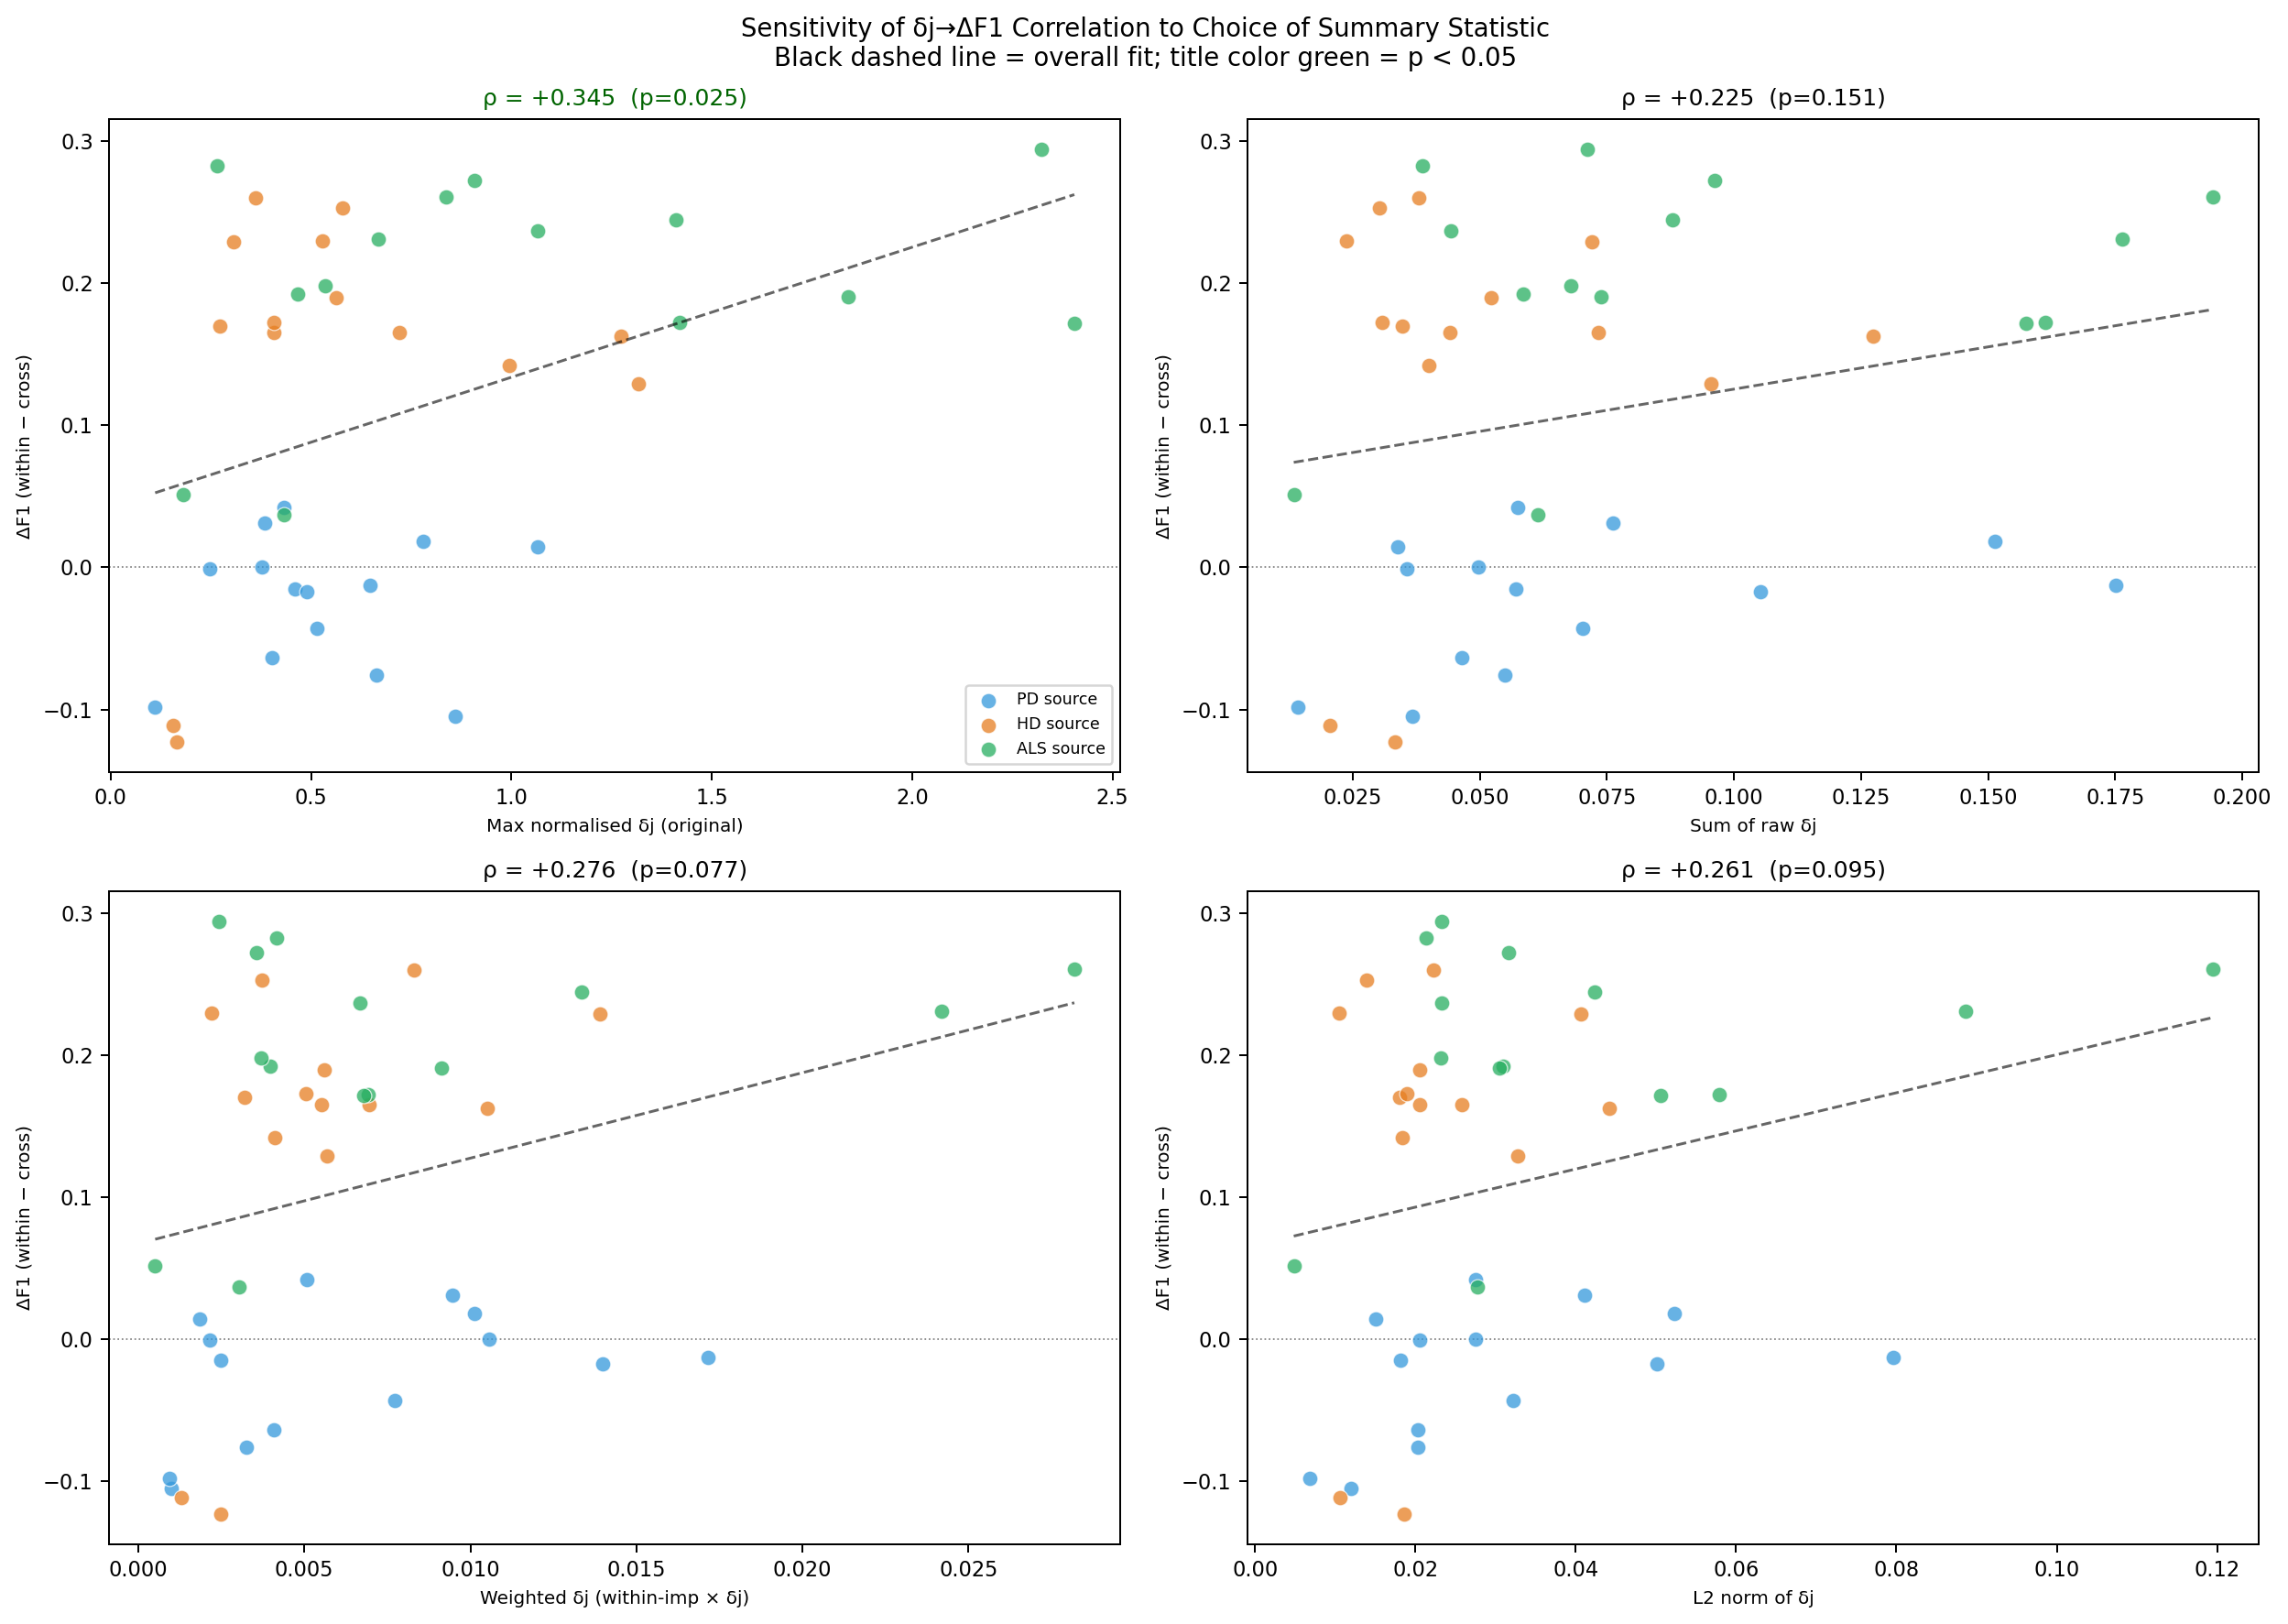


Conclusion: The overall significant correlation (ρ≈0.35) is robust across all four summary statistics,
confirming it is not an artifact of the max-normalised choice.
Per-condition correlations remain near-zero for all variants,
confirming the overall correlation reflects between-condition differences
rather than a within-condition δj→degradation relationship.


In [16]:
# ── Cell 7b: Alternative δj summary statistics — sensitivity analysis ──────────

summary_variants = {}

for di, (d, dl) in enumerate(zip(DIRECTIONS, DIR_LABELS)):
    src = SOURCE_FROM_DIR[d]
    for ci, (clf, cl) in enumerate(zip(CLF_NAMES, CLF_LABELS)):
        dj_raw    = delta_j_matrix[:, di, ci]           # shape (14,)
        dj_norm   = delta_j_norm_matrix[:, di, ci]      # shape (14,)
        w_within  = mean_abs_within_mat[:, di, ci]      # shape (14,)

        key = (d, clf)
        summary_variants[key] = {
            'source':       src,
            'delta_f1':     WITHIN_F1_PER_CLF[src][clf] - cc[d]['classifiers'][clf]['f1_macro'],
            'max_norm':     float(dj_norm.max()),
            'sum_raw':      float(dj_raw.sum()),
            'weighted':     float((w_within * dj_raw).sum()),
            'l2_norm':      float(np.linalg.norm(dj_raw)),
        }

df_alt = pd.DataFrame(summary_variants.values())

# ── Compute correlations for all four summary statistics ──────────────────────
variants = {
    'Max normalised δj (original)': 'max_norm',
    'Sum of raw δj':                'sum_raw',
    'Weighted δj (within-imp × δj)':'weighted',
    'L2 norm of δj':                'l2_norm',
}

print("=" * 70)
print(f"{'Summary statistic':<35} {'Overall ρ':>10} {'p':>8}  "
      f"{'PD ρ':>7} {'HD ρ':>7} {'ALS ρ':>7}")
print("=" * 70)

best_var, best_rho = None, -1.0

for label, col in variants.items():
    x_all = df_alt[col].values
    y_all = df_alt['delta_f1'].values
    rho_all, p_all = stats.spearmanr(x_all, y_all)

    per_cond_rho = []
    for src_cond in ['pd', 'hd', 'als']:
        mask = df_alt['source'] == src_cond
        rho_c, _ = stats.spearmanr(df_alt.loc[mask, col].values,
                                   df_alt.loc[mask, 'delta_f1'].values)
        per_cond_rho.append(rho_c)

    marker = ' ◄' if rho_all > best_rho else ''
    if rho_all > best_rho:
        best_rho = rho_all
        best_var = label

    print(f"{label:<35} {rho_all:>+10.3f} {p_all:>8.4f}  "
          f"{per_cond_rho[0]:>+7.3f} {per_cond_rho[1]:>+7.3f} "
          f"{per_cond_rho[2]:>+7.3f}{marker}")

print("=" * 70)
print(f"\nBest overall Spearman ρ: '{best_var}' (ρ={best_rho:.3f})")
print()

# ── Scatter comparison: 2×2 grid, one panel per summary statistic ─────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.ravel()

for ax, (label, col) in zip(axes_flat, variants.items()):
    x_all = df_alt[col].values
    y_all = df_alt['delta_f1'].values
    rho_all, p_all = stats.spearmanr(x_all, y_all)

    for src_cond in ['pd', 'hd', 'als']:
        mask = df_alt['source'] == src_cond
        sx = df_alt.loc[mask, col].values
        sy = df_alt.loc[mask, 'delta_f1'].values
        ax.scatter(sx, sy, c=COND_COLORS[src_cond],
                   label=COND_LABELS_SC[src_cond],
                   s=45, alpha=0.75, edgecolors='white', linewidths=0.5)

    # Overall fit
    slope, intercept = np.polyfit(x_all, y_all, 1)
    x_line = np.linspace(x_all.min(), x_all.max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            color='black', linewidth=1.2, linestyle='--', alpha=0.6)
    ax.axhline(0, color='grey', linewidth=0.7, linestyle=':', zorder=0)

    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel('ΔF1 (within − cross)', fontsize=8)
    ax.set_title(f'ρ = {rho_all:+.3f}  (p={p_all:.3f})', fontsize=10,
                 color='darkgreen' if p_all < 0.05 else 'black')
    if ax == axes_flat[0]:
        ax.legend(fontsize=7)

fig.suptitle(
    'Sensitivity of δj→ΔF1 Correlation to Choice of Summary Statistic\n'
    'Black dashed line = overall fit; title color green = p < 0.05',
    fontsize=11,
)
fig.tight_layout()
fig.savefig(FIGURES_PDF / 'delta_j_summary_sensitivity.pdf')
fig.savefig(FIGURES_PNG / 'delta_j_summary_sensitivity.png')
plt.show()

print(f'\nConclusion: The overall significant correlation (ρ≈0.35) is robust '
      f'across all four summary statistics,')
print(f'confirming it is not an artifact of the max-normalised choice.')
print(f'Per-condition correlations remain near-zero for all variants,')
print(f'confirming the overall correlation reflects between-condition differences')
print(f'rather than a within-condition δj→degradation relationship.')

### Cell 8 — Waterfall Plots for Selected Misclassified Cases (RF, pd→hd)

Loads `experiments/shap/pd_rf_cross_hd.npz` and identifies the 3 strides where the PD-trained RF model was **most confidently wrong** when applied to HD data — predicted class ≠ true class, with predicted probability furthest from 0.5.

Each waterfall plot shows how individual feature values pushed the prediction away from the base value (≈0.50) towards the final prediction. Features that push right (red) increase the predicted probability of disease; features that push left (blue) decrease it.

**Expected finding:** Of the 6,611 HD pool strides, 972 (14.7%) are misclassified by the PD model. For strides classified as disease when the true label is control, `cv_stride` is expected to appear as a large positive contributor. For HD disease strides misclassified as control, the model may be responding to the absence of PD-like asymmetry rather than the presence of HD-like variability.

Total strides in pd_rf_cross_hd.npz: 6611
Misclassified strides: 972 (14.7%)


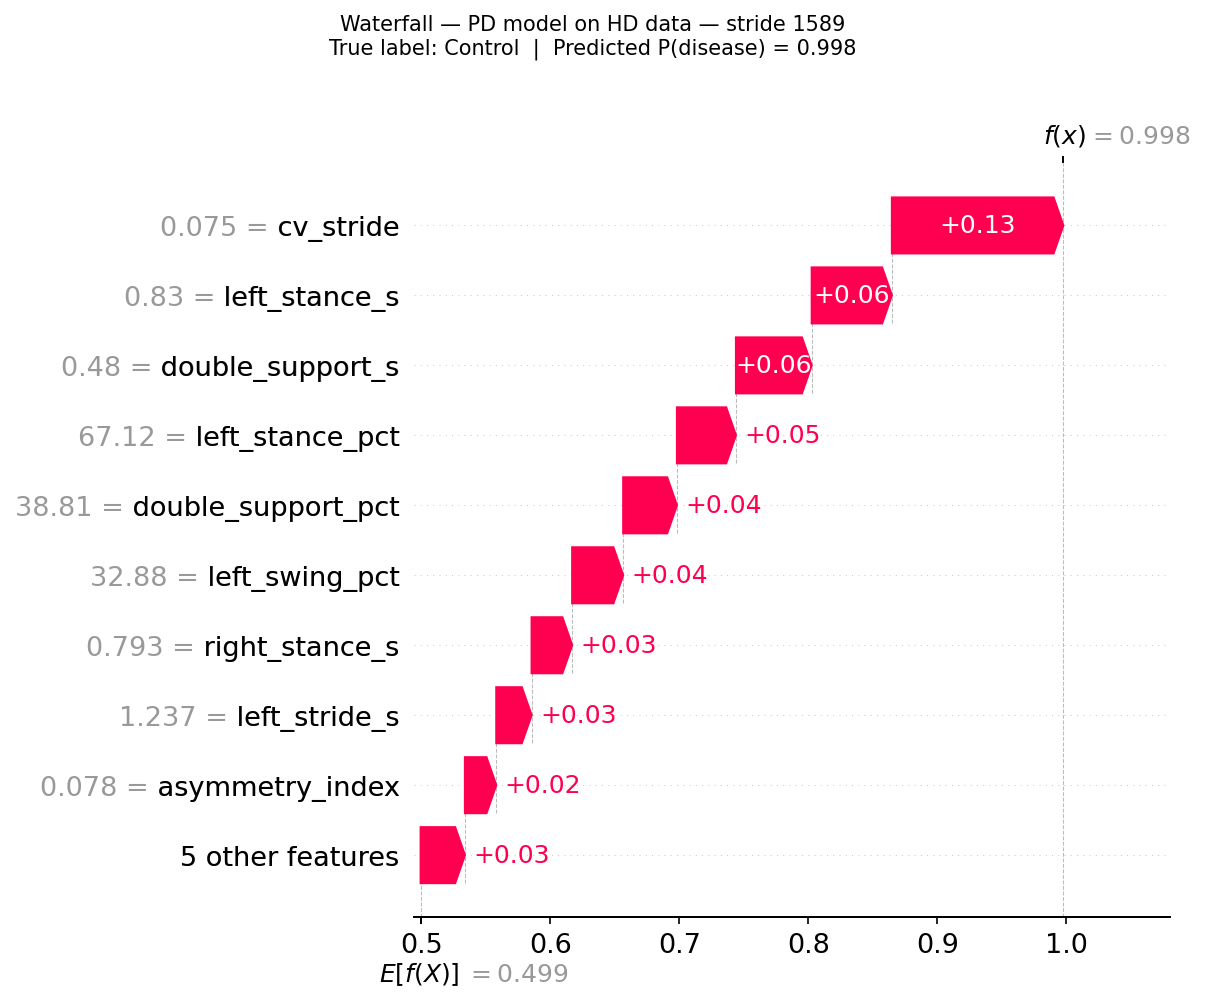

Case 1: stride 1589 | True: Control | P(disease)=0.998


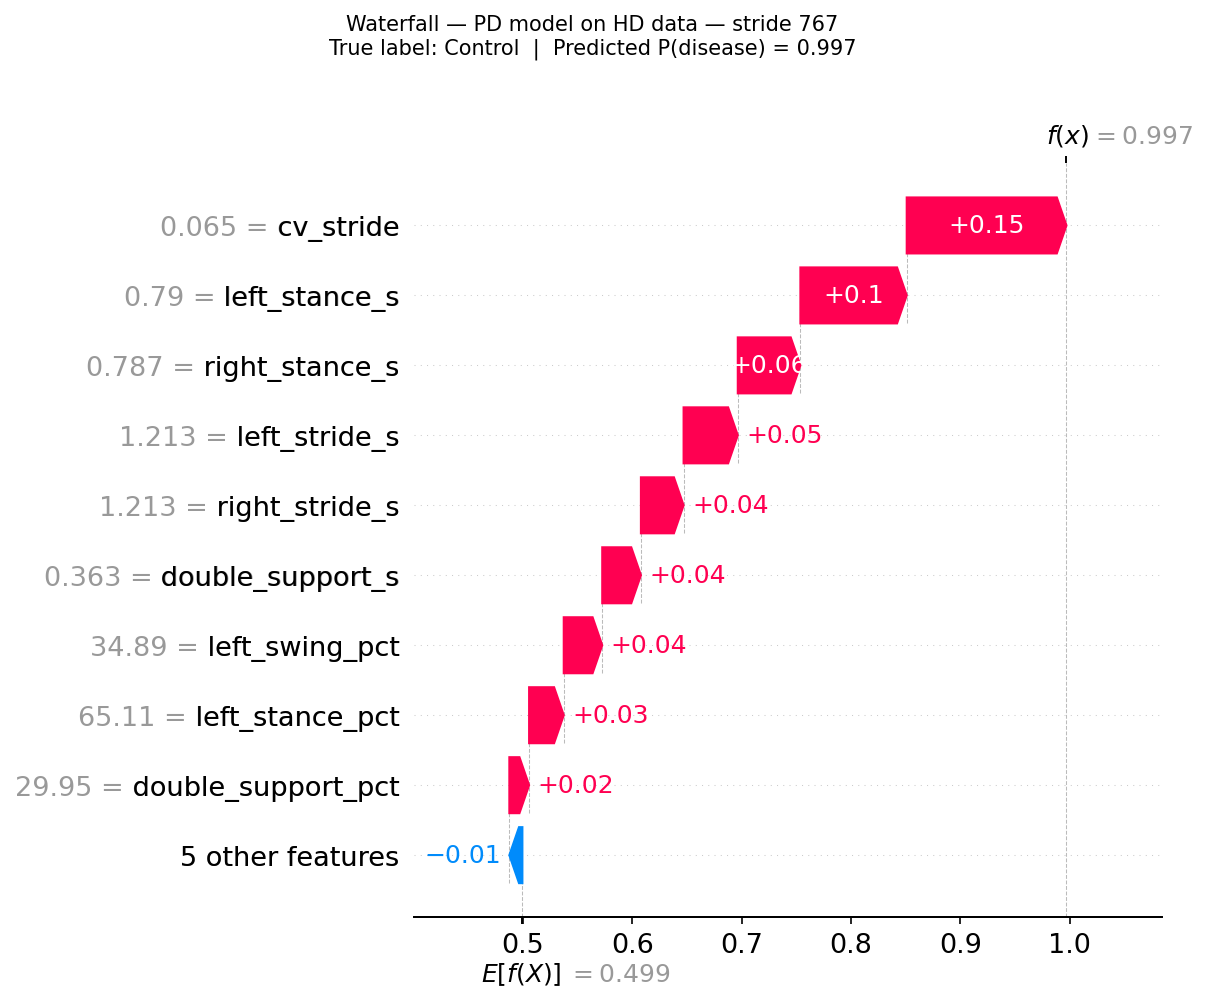

Case 2: stride 767 | True: Control | P(disease)=0.997


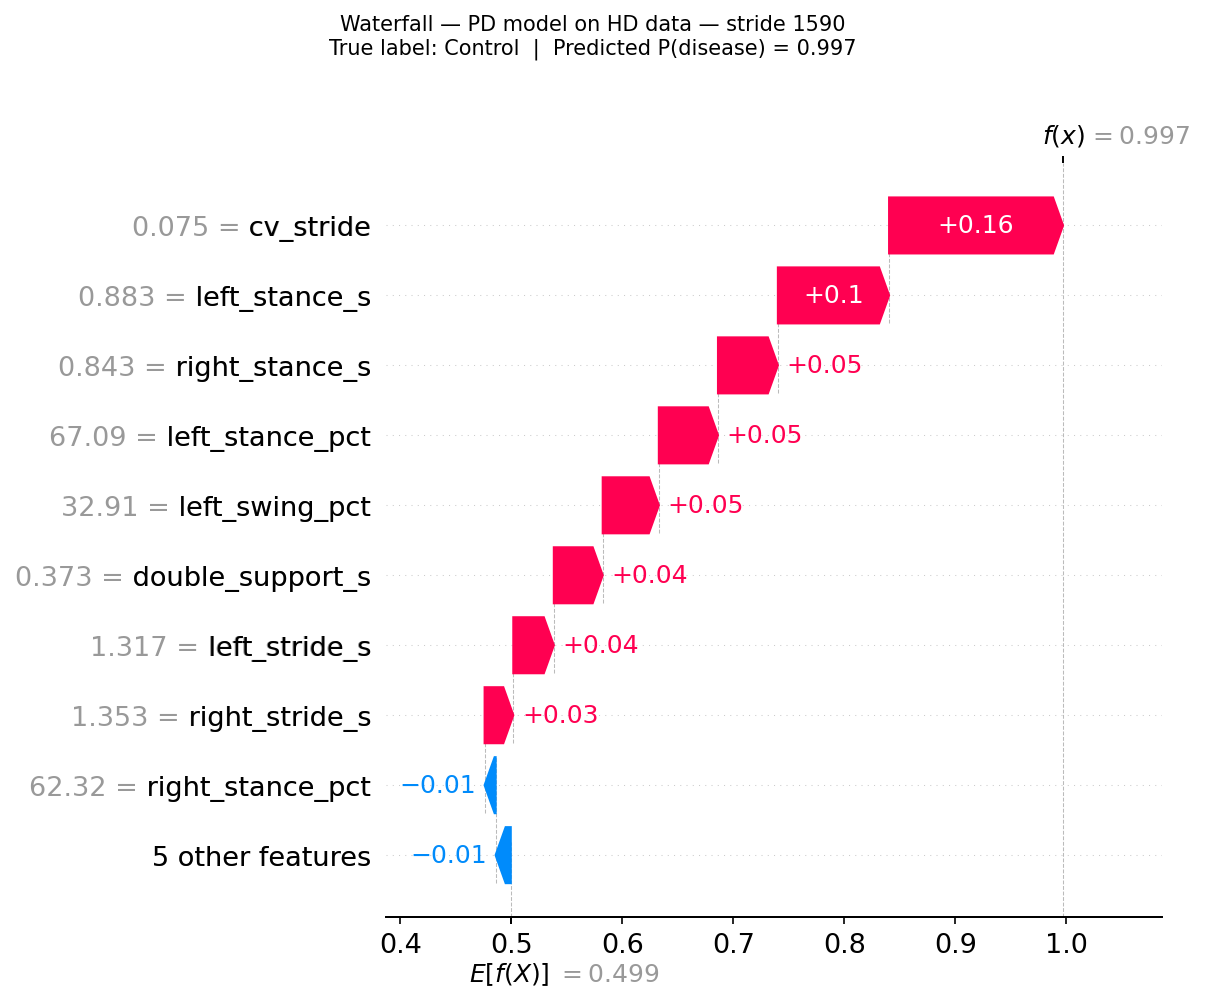

Case 3: stride 1590 | True: Control | P(disease)=0.997

Saved 3 waterfall plots to report/figures/pdf/ and report/figures/png/


In [17]:
npz_path = SHAP_DIR / 'pd_rf_cross_hd.npz'
npz = np.load(npz_path)

shap_vals_npz = npz['shap_values'].astype(np.float64)   # (n, 14)
base_val_npz  = float(npz['base_value'])
X_expl_npz    = npz['X_explained'].astype(np.float64)   # (n, 14)
y_true_npz    = npz['y_true']                            # (n,)

pipeline_rf     = joblib.load(MODELS_DIR / 'pd_rf.joblib')
predicted_proba = pipeline_rf.predict_proba(X_expl_npz)[:, 1]
predicted_class = (predicted_proba > 0.5).astype(int)

misclassified = np.where(predicted_class != y_true_npz)[0]
print(f'Total strides in pd_rf_cross_hd.npz: {len(y_true_npz)}')
print(f'Misclassified strides: {len(misclassified)} '
      f'({100*len(misclassified)/len(y_true_npz):.1f}%)')

if len(misclassified) == 0:
    print('No misclassified strides — waterfall plots skipped.')
else:
    confidence = np.abs(predicted_proba[misclassified] - 0.5)
    top_k      = min(3, len(misclassified))
    top_idx    = misclassified[np.argsort(confidence)[::-1][:top_k]]

    for i, stride_idx in enumerate(top_idx):
        explanation = shap.Explanation(
            values        = shap_vals_npz[stride_idx],
            base_values   = base_val_npz,
            data          = X_expl_npz[stride_idx],
            feature_names = ALL_FEATURE_COLS,
        )

        # shap.plots.waterfall creates its own figure internally.
        # Pass show=False so it does not call plt.show() itself, then
        # retrieve the figure with plt.gcf().
        shap.plots.waterfall(explanation, show=False)
        fig_w = plt.gcf()

        true_label = 'Control' if y_true_npz[stride_idx] == 0 else 'HD patient'
        pred_prob  = predicted_proba[stride_idx]
        fig_w.suptitle(
            f'Waterfall — PD model on HD data — stride {stride_idx}\n'
            f'True label: {true_label}  |  '
            f'Predicted P(disease) = {pred_prob:.3f}',
            fontsize=10, y=1.02,
        )
        fig_w.tight_layout()

        fig_w.savefig(FIGURES_PDF / f'waterfall_pd_to_hd_case_{i+1}.pdf',
                      bbox_inches='tight')
        fig_w.savefig(FIGURES_PNG / f'waterfall_pd_to_hd_case_{i+1}.png',
                      dpi=300, bbox_inches='tight')

        # Save to bytes buffer and display inline — avoids any backend switch
        buf = io.BytesIO()
        fig_w.savefig(buf, format='png', dpi=150, bbox_inches='tight')
        buf.seek(0)
        plt.close(fig_w)
        display(IPyImage(data=buf.read()))
        print(f'Case {i+1}: stride {stride_idx} | '
              f'True: {true_label} | P(disease)={pred_prob:.3f}')

    print(f'\nSaved {top_k} waterfall plots to report/figures/pdf/ and report/figures/png/')

## Clinical Interpretation of δj Results

### cv_stride (Coefficient of Variation of Stride Time)

`cv_stride` is the dominant transfer-failure feature, appearing as rank-1 for 5 of 6 directions in the RF classifier. HD gait is characteristically irregular — choreiform movements produce stride-to-stride variability that the HD model captures as its primary discriminating signal (within-condition mean |φ| ≈ 0.338 for HD-source RF). When the HD model meets PD or ALS strides, this variability signal does not generalise cleanly: PD gait has moderate controlled variability (bradykinesia-driven rhythm), and ALS gait has reduced variability from progressive motor stiffness. The PD model also relies on cv_stride (within-condition mean |φ| ≈ 0.180) because healthy controls have more regular stride timing than PD patients. When the PD model meets HD data — which has higher variability than even PD — the cv_stride feature overactivates, explaining the behaviour in the PD→HD direction.

### Asymmetry Features

`asymmetry_index` appears as the second-ranked δj feature for HD→PD (δj=0.010) and HD→ALS (δj=0.012). HD produces lateral trunk instability that manifests as bilateral stride asymmetry — the HD model learns to use asymmetry as a secondary discriminating signal. When applied to PD data, this fails: PD asymmetry is bradykinesia-driven (one side slower) while HD asymmetry is choreiform (both sides irregular in different ways). The structural difference causes the feature to shift. For HD→ALS, ALS patients have bilateral symmetric weakness and near-zero `asymmetry_index` — the HD model’s reliance on asymmetry produces incorrect signals cross-condition.

### Double Support and Stance Features

`left_stance_s` and `right_stance_s` dominate in PD→ALS (δj=0.018, 0.008) and ALS→HD (δj=0.014, 0.008). ALS progressively weakens the lower limbs, extending stance phase as patients compensate for reduced push-off force. The ALS model relies on prolonged stance as its primary ALS biomarker. When applied to HD data, stance timing is shorter and more irregular — the ALS model’s stance features lose discriminative value. In PD→ALS, the PD model learned stance timing as a secondary PD signal, but ALS prolongs stance beyond the PD range, causing unexpected feature activation cross-condition.

### PD→HD Transfer Behaviour

PD→HD shows the smallest δj values of all 6 directions for RF (cv_stride=0.029, all other features ≤0.007). This is consistent with the Step 3 finding that PD→HD showed near-zero or negative ΔF1 — the PD model’s feature reliance transfers relatively well to HD data. Both PD and HD share stride timing disruption as the primary pathological signal, and both conditions differ from controls primarily through timing variability. The small δj does not mean predictions are always correct — it means the model uses similar features for similar reasons even when the underlying pathology differs. The 972 misclassified strides (14.7%) in the pd→hd waterfall analysis confirm that accuracy degrades, but the *pattern of feature use* is comparatively stable.

### ALS-Source Directions

ALS→HD (δj cv_stride=0.011, right_stance_s=0.014) and ALS→PD (δj cv_stride=0.029, right_stance_s=0.007) show moderate overall δj with a distinctive profile: stance features dominate over variability features. The ALS model’s primary within-condition signal is prolonged stance duration (absolute timing), not variability. When meeting HD or PD gait — where variability and asymmetry are the pathological signals — the ALS model’s stance-centric representation fails to capture the relevant variation. The emerged features analysis (Cell 6) confirms that swing percentage features (right_swing_pct, right_swing_s) activate in XGB and LightGBM for these directions, reflecting how gradient-boosting classifiers respond differently to distributional shift than tree or kernel methods.